In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import mca
import prince
from scipy.stats import chi2_contingency
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import altair as alt
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from prophet import Prophet
from bokeh.plotting import figure, show, output_notebook
import squarify
from wordcloud import WordCloud
pio.renderers.default = "png"

# --- CONFIGURACIÓN DE DISEÑO DE ALTO NIVEL ---
sns.set_theme(style="white", context="talk")
plt.rcParams.update({
    "figure.figsize": (14, 8),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
    "axes.titleweight": "bold",
    "axes.titlesize": 18,
    "axes.labelweight": "bold",
    "figure.dpi": 100
})
custom_palette = sns.color_palette("viridis", as_cmap=False)
sns.set_palette("viridis")
# --------------------------------------------

output_notebook()
from sklearn.ensemble import IsolationForest
import plotly.subplots as sp
import networkx as nx
import plotly.figure_factory as ff


Loading BokehJS ...

# Diccionario de Datos y Metadatos

Este proyecto analiza el absentismo docente basado en registros administrativos de una Secretaría de Educación. A continuación se detallan las variables principales:

| Variable | Descripción | Significado Sugerido |
| :--- | :--- | :--- |
| **CEDULA** | Identificación | ID único anonimizado del docente. |
| **TIPO** | Vinculación General | **1**: Planta/Permanente, **2**: Provisional/Temporal. |
| **SUBTIPO** | Detalle de Novedad | Código específico del trámite (ej. 1: Ascenso, 8: Ajuste Salarial, 15: Ingreso). |
| **INICIO_OCURRENCIA** | Fecha Inicio | Cuándo inicia la ausencia o novedad administrativa. |
| **DIAS HABILES** | Duración | Días efectivos que el docente no estuvo en su puesto normal. |
| **SEXO** | Género | F: Femenino, M: Masculino. |
| **CARGOEMPRESA** | Rol Laboral | Docente de aula, Coordinador, Orientador, Rector, Administrativo. |
| **NOMBRE_SEDE** | Ubicación | Institución educativa y sede específica (ej. Rural Antonio Nariño). |
| **VINCULACIONNOVEDAD**| Proceso | Naturaleza del movimiento (Traslados, Cambios de Sueldo, Prórrogas). |
| **SITUACIONLABORAL** | Estado Actual | Normal, Reemplazo, Encargo, Vacante. |

## Notas sobre el Absentismo
En este contexto, el "absentismo" no solo implica enfermedad, sino cualquier **novedad administrativa** que retire al docente de su labor cotidiana (comisiones, permisos, traslados, etc.). Los **Días Hábiles** son el KPI principal para medir el impacto en la continuidad educativa.

In [2]:
import os
# Intento de carga robusta de datos
possible_paths = ["../data/Consolidado.xlsx", "data/Consolidado.xlsx", "Consolidado.xlsx"]
data_path = None
for p in possible_paths:
    if os.path.exists(p):
        data_path = p
        break
if data_path:
    datos_total = pd.read_excel(data_path)
    print(f"Datos cargados desde: {data_path}")
else:
    raise FileNotFoundError("No se encontró Consolidado.xlsx en las rutas esperadas.")


Datos cargados desde: ../data/Consolidado.xlsx


# Tablero Ejecutivo de Absentismo (KPIs Críticos)
Resumen de alto nivel para la toma de decisiones inmediata.

In [3]:
# Visualización de KPIs con Estilo de Tablero
from IPython.display import HTML

total_dias = datos_total["DIAS HABILES"].sum()
promedio_dias = datos_total["DIAS HABILES"].mean()
total_casos = len(datos_total)

html_kpis = f"""
<div style="display: flex; justify-content: space-around; background-color: #f8f9fa; padding: 20px; border-radius: 10px; border: 1px solid #dee2e6;">
    <div style="text-align: center;">
        <h2 style="color: #4a4a4a; margin-bottom: 5px;">{total_dias:,.0f}</h2>
        <p style="color: #6c757d; font-size: 14px;">Total Días de Ausencia</p>
    </div>
    <div style="text-align: center; border-left: 1px solid #dee2e6; border-right: 1px solid #dee2e6; padding: 0 40px;">
        <h2 style="color: #4a4a4a; margin-bottom: 5px;">{promedio_dias:.2f}</h2>
        <p style="color: #6c757d; font-size: 14px;">Promedio Días / Caso</p>
    </div>
    <div style="text-align: center;">
        <h2 style="color: #4a4a4a; margin-bottom: 5px;">{total_casos:,.0f}</h2>
        <p style="color: #6c757d; font-size: 14px;">Total de Registros</p>
    </div>
</div>
"""
display(HTML(html_kpis))


In [4]:
datos_total.head()

,CEDULA,TIPO,SUBTIPO,INICIO_OCURRENCIA,DIA DE LA SEMANA,DIAS HABILES,SEXO,CODCARGOEMPRESA,CARGOEMPRESA,CODCARGO,...,SITUACIONLABORAL,CODDEPENDENCIA,DEPENDENCIA,DIRECCION,CODCIUDADRESIDENCIA,birth_date,EDAD,FEMENINO,RANGO DE EDAD,FECHA INICIAL
0,52328786,1,2,2021-03-25,5,55,F,9001.0,Docente de aula,900.0,...,Normal,C256580011502,CONCENTARCION URBANA ANTONIA SANTOS (Primaria),CALLE 3 # 3-60,25154.0,1974-09-24,47.0,1,46-55,2021-03-25
1,41570594,1,2,2021-08-12,5,60,F,9001.0,Docente de aula,900.0,...,Normal,C258170020402,ESCUELA RURAL LA ESMERALDA (Primaria),KRA 38 # 2C-11,11001.0,1952-07-25,69.0,1,66+,2021-08-12
2,39727960,1,1,2021-10-09,7,21,F,9001.0,Docente de aula,900.0,...,Normal,C251510010502,ESCUELA URBANA CARLOS JOSE ROMERO (Primaria),CLL 3 N 5-03,25151.0,1965-04-29,56.0,1,56-65,2021-10-09
3,52982139,1,1,2021-09-07,3,29,F,9001.0,Docente de aula,900.0,...,Normal,C251200012002,ESC. RURAL ALTO ARIARI 2 (Primaria),VEREDA EL TAPAZ FINCA LA VIRGEN EL PEÑON,25258.0,1983-03-23,38.0,1,36-45,2021-09-07
4,79694188,1,2,2021-08-05,5,30,M,9003.0,Docente Orientador,900.0,...,Normal,C2549100301,I.E. DEPARTAMENTAL NORMAL SUPERIOR - SEDE PRIN...,CARRERA 102 N° 155B - 03 TORRE 8 APT 204,11001.0,1975-08-28,46.0,0,46-55,2021-08-05


In [5]:
datos_total.info()

<class 'pandas.DataFrame'>
RangeIndex: 7234 entries, 0 to 7233
Data columns (total 49 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   CEDULA                                       7234 non-null   int64         
 1   TIPO                                         7234 non-null   int64         
 2   SUBTIPO                                      7234 non-null   int64         
 3   INICIO_OCURRENCIA                            7234 non-null   datetime64[us]
 4   DIA DE LA SEMANA                             7234 non-null   int64         
 5   DIAS HABILES                                 7234 non-null   int64         
 6   SEXO                                         7167 non-null   str           
 7   CODCARGOEMPRESA                              7167 non-null   float64       
 8   CARGOEMPRESA                                 7167 non-null   str           
 9   CODCARGO

In [6]:
tabla_contingencia = pd.crosstab(datos_total['EDAD'], [datos_total['TIPO'], datos_total['SUBTIPO'], datos_total['FEMENINO']], margins=True)

In [7]:
tabla_contingencia

TIPO        1                          2               ...                 \
SUBTIPO     1         2         3  4   6       7    8  ... 17 18       19   
FEMENINO    0     1   0    1    1  0   0    1  1    0  ...  1  0   1    0   
EDAD                                                   ...                  
20.0        0     0   0    0    0  0   0    0  0    0  ...  0  0   0    0   
23.0        0     0   0    0    0  0   0    0  0    0  ...  0  0   0    0   
24.0        0     0   0    0    0  0   0    0  0    1  ...  0  0   0    0   
25.0        0     0   1    0    0  0   0    1  0    0  ...  0  0   0    0   
26.0        1     5   0    0    0  0   0    0  0    4  ...  0  0   0    0   
27.0        1     4   0    2    3  0   0    0  0    0  ...  0  0   0    0   
28.0        0     5   0    0    1  0   1    0  0    5  ...  1  0   0    0   
29.0        2    10   0    2   10  0   0    2  0    0  ...  0  0   1    0   
30.0        4    12   0    0   10  0   0    0  0    4  ...  0  0   0    5   
31.0        3     4   0    1    7  0   0    4  0    5  ...  0  0   0    2   
32.0        2    13   0    1    7  0   0    1  0   11  ...  0  0   0    0   
33.0       10    24   1    3   12  0   0    0  0   12  ...  0  0   0    4   
34.0        8    17   0   12    9  0   1    4  0   19  ...  0  0   0    3   
35.0       33    33   2    8   14  0   2    4  0   10  ...  0  0   0    1   
36.0        3    20   2    2    9  0   2    1  0    7  ...  0  0   0    5   
37.0       13    27   6    2   14  0   2    5  0   14  ...  0  0   1    3   
38.0        8    36   3    1    7  1   2    3  0    5  ...  0  0   0    1   
39.0        5    31   0    6    6  0   1    1  0    6  ...  0  0   2    2   
40.0       16    44   0   23    8  0   5    2  0    7  ...  0  0   1    5   
41.0       12    33  14    8    4  0   2    4  0   21  ...  0  0   2    8   
42.0        6    61   4   10    7  0   3   10  0   17  ...  0  0   0    8   
43.0        9    25   0    2    2  0   1    3  0   15  ...  0  0   0    3   
44.0        6    14   0    7    0  0   1    2  0   11  ...  0  0   0   14   
45.0        7    28   1   20    1  0   2    2  0    8  ...  0  0   0    4   
46.0        5    14  12   19    0  0   3    6  0   28  ...  0  0   0    1   
47.0       15    28   6    9    0  0   0    3  0    9  ...  0  0   0    5   
48.0        4    18   0   14    0  0   0    8  0   11  ...  0  0   0    3   
49.0        5    54   0   18    0  0   5    1  0   15  ...  0  0   1    6   
50.0        4    61   7   30    0  0   0    2  0   10  ...  0  0   1    0   
51.0       13    22   0    7    0  0   0    2  0    4  ...  0  0   0    2   
52.0        4    19   8   31    0  0   1    3  0   12  ...  0  0   1    0   
53.0        1    31   0   23    0  0   2    5  0    6  ...  0  1   0    5   
54.0       12    56   1   13    0  0   2    4  0    6  ...  0  1   1    2   
55.0        8    36   2    2    0  0   1    4  0   16  ...  0  0   0    1   
56.0        4    40   1   13    0  0   0    8  0    3  ...  0  0   1    1   
57.0        5    26   0    6    0  0   3    4  0   13  ...  0  2   0    4   
58.0       14    30   0   17    0  0   1    1  0    6  ...  0  0   0    1   
59.0       15    37   3   30    0  0   3    4  0    8  ...  0  0   1    4   
60.0       17    18   1    6    0  0   1    4  1   10  ...  0  0   1    2   
61.0        1    69   0    4    0  0   3    5  0   11  ...  0  0   0    3   
62.0        0    41   0   11    0  0   1    0  0    5  ...  0  0   0    2   
63.0        4    47   0    1    0  0   1    3  0    6  ...  0  0   0    1   
64.0       18    28   4    4    0  0   0    1  0   15  ...  0  0   0    2   
65.0        6    54   4    2    0  0   2    2  0    9  ...  0  0   0    3   
66.0        8    31   0   16    0  0   1    0  0    2  ...  0  0   0    0   
67.0       14     6  11   10    0  0   1    2  0    7  ...  0  0   0    3   
68.0        0     5   0    1    0  0   0    0  0    1  ...  0  0   0    0   
69.0        9     2   0    7    0  0   0    2  0   11  ...  0  0   0    0

In [8]:
#Tabla de contingencia relativa
tabla_contingencia_r = pd.crosstab(index=datos_total['EDAD'], columns=([datos_total['TIPO'], datos_total['SUBTIPO'], datos_total['FEMENINO']]),
            margins=True).apply(lambda r: r/len(datos_total) *100,
                                axis=1)
tabla_contingencia_r

TIPO             1                                                     \
SUBTIPO          1                    2                   3         4   
FEMENINO         0          1         0         1         1         0   
EDAD                                                                    
20.0      0.000000   0.000000  0.000000  0.000000  0.000000  0.000000   
23.0      0.000000   0.000000  0.000000  0.000000  0.000000  0.000000   
24.0      0.000000   0.000000  0.000000  0.000000  0.000000  0.000000   
25.0      0.000000   0.000000  0.013824  0.000000  0.000000  0.000000   
26.0      0.013824   0.069118  0.000000  0.000000  0.000000  0.000000   
27.0      0.013824   0.055294  0.000000  0.027647  0.041471  0.000000   
28.0      0.000000   0.069118  0.000000  0.000000  0.013824  0.000000   
29.0      0.027647   0.138236  0.000000  0.027647  0.138236  0.000000   
30.0      0.055294   0.165883  0.000000  0.000000  0.138236  0.000000   
31.0      0.041471   0.055294  0.000000  0.013824  0.096765  0.000000   
32.0      0.027647   0.179707  0.000000  0.013824  0.096765  0.000000   
33.0      0.138236   0.331767  0.013824  0.041471  0.165883  0.000000   
34.0      0.110589   0.235001  0.000000  0.165883  0.124412  0.000000   
35.0      0.456179   0.456179  0.027647  0.110589  0.193531  0.000000   
36.0      0.041471   0.276472  0.027647  0.027647  0.124412  0.000000   
37.0      0.179707   0.373237  0.082942  0.027647  0.193531  0.000000   
38.0      0.110589   0.497650  0.041471  0.013824  0.096765  0.013824   
39.0      0.069118   0.428532  0.000000  0.082942  0.082942  0.000000   
40.0      0.221178   0.608239  0.000000  0.317943  0.110589  0.000000   
41.0      0.165883   0.456179  0.193531  0.110589  0.055294  0.000000   
42.0      0.082942   0.843240  0.055294  0.138236  0.096765  0.000000   
43.0      0.124412   0.345590  0.000000  0.027647  0.027647  0.000000   
44.0      0.082942   0.193531  0.000000  0.096765  0.000000  0.000000   
45.0      0.096765   0.387061  0.013824  0.276472  0.013824  0.000000   
46.0      0.069118   0.193531  0.165883  0.262649  0.000000  0.000000   
47.0      0.207354   0.387061  0.082942  0.124412  0.000000  0.000000   
48.0      0.055294   0.248825  0.000000  0.193531  0.000000  0.000000   
49.0      0.069118   0.746475  0.000000  0.248825  0.000000  0.000000   
50.0      0.055294   0.843240  0.096765  0.414708  0.000000  0.000000   
51.0      0.179707   0.304119  0.000000  0.096765  0.000000  0.000000   
52.0      0.055294   0.262649  0.110589  0.428532  0.000000  0.000000   
53.0      0.013824   0.428532  0.000000  0.317943  0.000000  0.000000   
54.0      0.165883   0.774122  0.013824  0.179707  0.000000  0.000000   
55.0      0.110589   0.497650  0.027647  0.027647  0.000000  0.000000   
56.0      0.055294   0.552944  0.013824  0.179707  0.000000  0.000000   
57.0      0.069118   0.359414  0.000000  0.082942  0.000000  0.000000   
58.0      0.193531   0.414708  0.000000  0.235001  0.000000  0.000000   
59.0      0.207354   0.511474  0.041471  0.414708  0.000000  0.000000   
60.0      0.235001   0.248825  0.013824  0.082942  0.000000  0.000000   
61.0      0.013824   0.953829  0.000000  0.055294  0.000000  0.000000   
62.0      0.000000   0.566768  0.000000  0.152060  0.000000  0.000000   
63.0      0.055294   0.649710  0.000000  0.013824  0.000000  0.000000   
64.0      0.248825   0.387061  0.055294  0.055294  0.000000  0.000000   
65.0      0.082942   0.746475  0.055294  0.027647  0.000000  0.000000   
66.0      0.110589   0.428532  0.000000  0.221178  0.000000  0.000000   
67.0      0.193531   0.082942  0.152060  0.138236  0.000000  0.000000   
68.0      0.000000   0.069118  0.000000  0.013824  0.000000  0.000000   
69.0      0.124412   0.027647  0.000000  0.096765  0.000000  0.000000   
70.0      0.082942   0.000000  0.000000  0.000000  0.000000  0.000000   
71.0      0.055294   0.000000  0.000000  0.000000  0.000000  0.000000   
All       4.769146  16.850981  1.299419  5.584739  1.81089

In [9]:
# Utilizamos la función chi2_contingency para calcular el índice de Chi-cuadrado y el p-valor
chi2, p, dof, expected = chi2_contingency(tabla_contingencia.drop('All', axis=0).drop('All', axis=1, level=0))
# Si el p-valor es menor que 0.05, podemos decir que existe una relación significativa entre las variables
if p < 0.05:
    print("Existe una relación significativa entre las variables (p = {})".format(p))
else:
    print("No existe una relación significativa entre las variables (p = {})".format(p))

Existe una relación significativa entre las variables (p = 2.4040989955492e-173)


In [10]:
# 3. Coeficiente Phi para variables binarias (Ejemplo con SEXO vs TIPO binario)
def get_phi(c_matrix):
    if c_matrix.shape == (2, 2):
        a, b = c_matrix[0, 0], c_matrix[0, 1]
        c, d = c_matrix[1, 0], c_matrix[1, 1]
        denom = np.sqrt(float(a + b) * (c + d) * (a + c) * (b + d))
        if denom == 0: return 0
        return (a * d - b * c) / denom
    return 0

# Ejemplo: Tabla 2x2 para SEXO vs Alguna Condición (binarizando TIPO)
datos_total['TIPO_BIN'] = (datos_total['TIPO'] == datos_total['TIPO'].unique()[0]).astype(int)
c_table_2x2 = pd.crosstab(datos_total['FEMENINO'], datos_total['TIPO_BIN'])
phi_val = get_phi(c_table_2x2.values)
print(f"Coeficiente Phi (Sexo vs Tipo Binario): {phi_val:.4f}")


Coeficiente Phi (Sexo vs Tipo Binario): 0.1028


In [11]:
dat=datos_total.to_numpy()

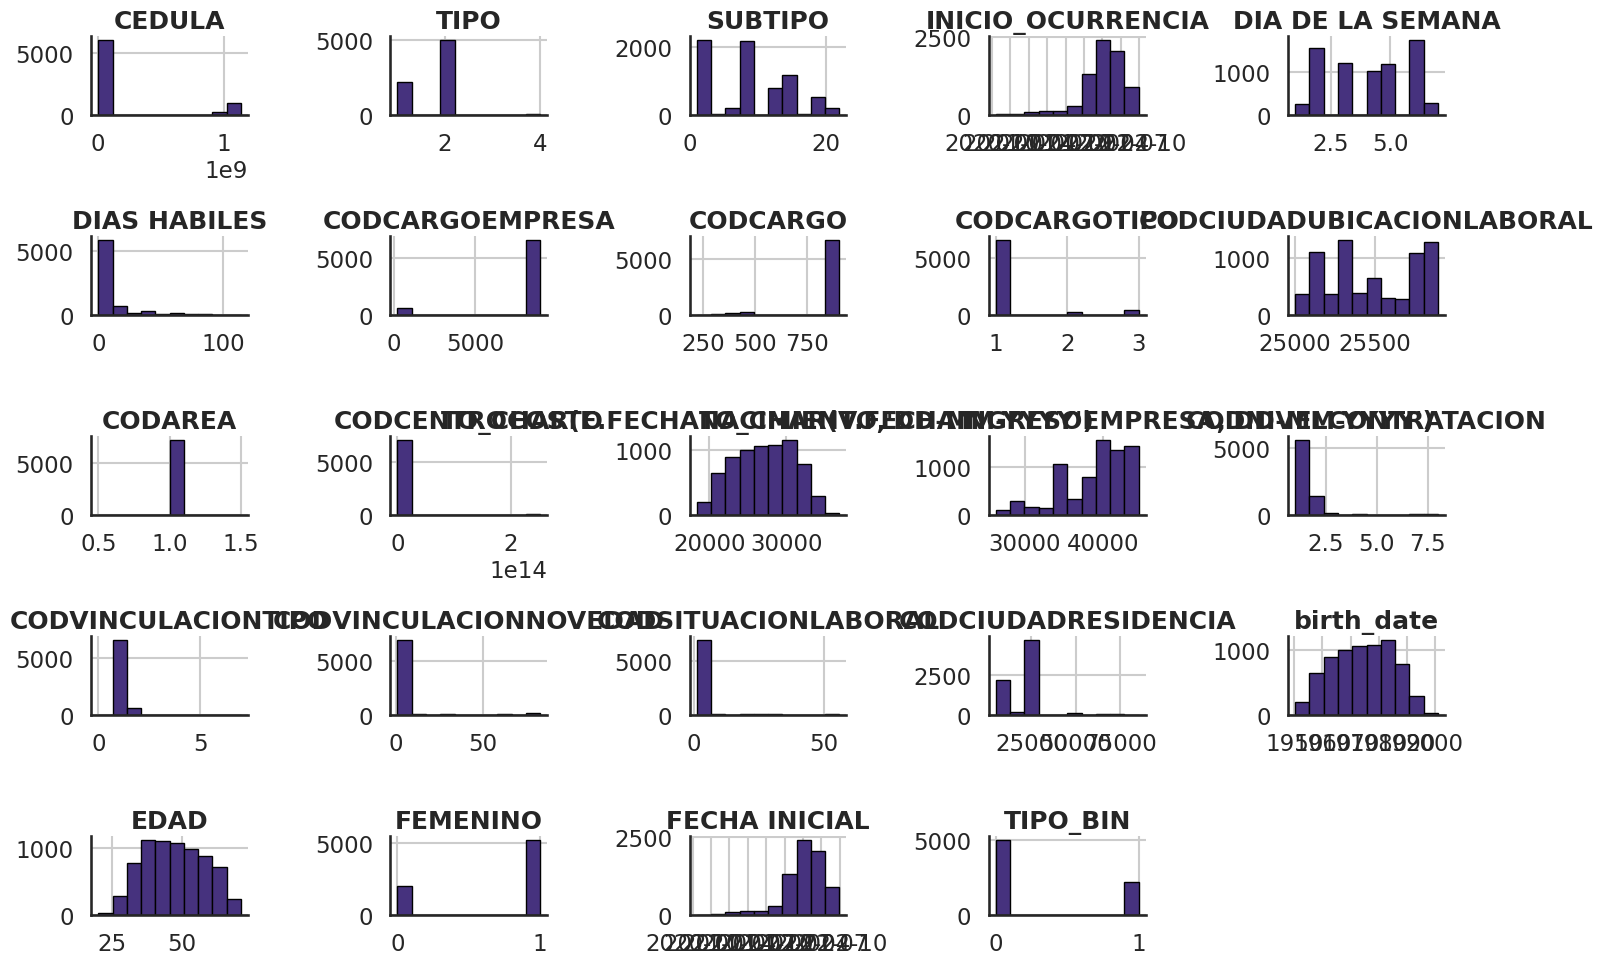

In [12]:
# Visualización de la distribución de variables numéricas
datos_total.hist(edgecolor="black", linewidth=1, figsize=(15, 10))
plt.tight_layout()
plt.show()


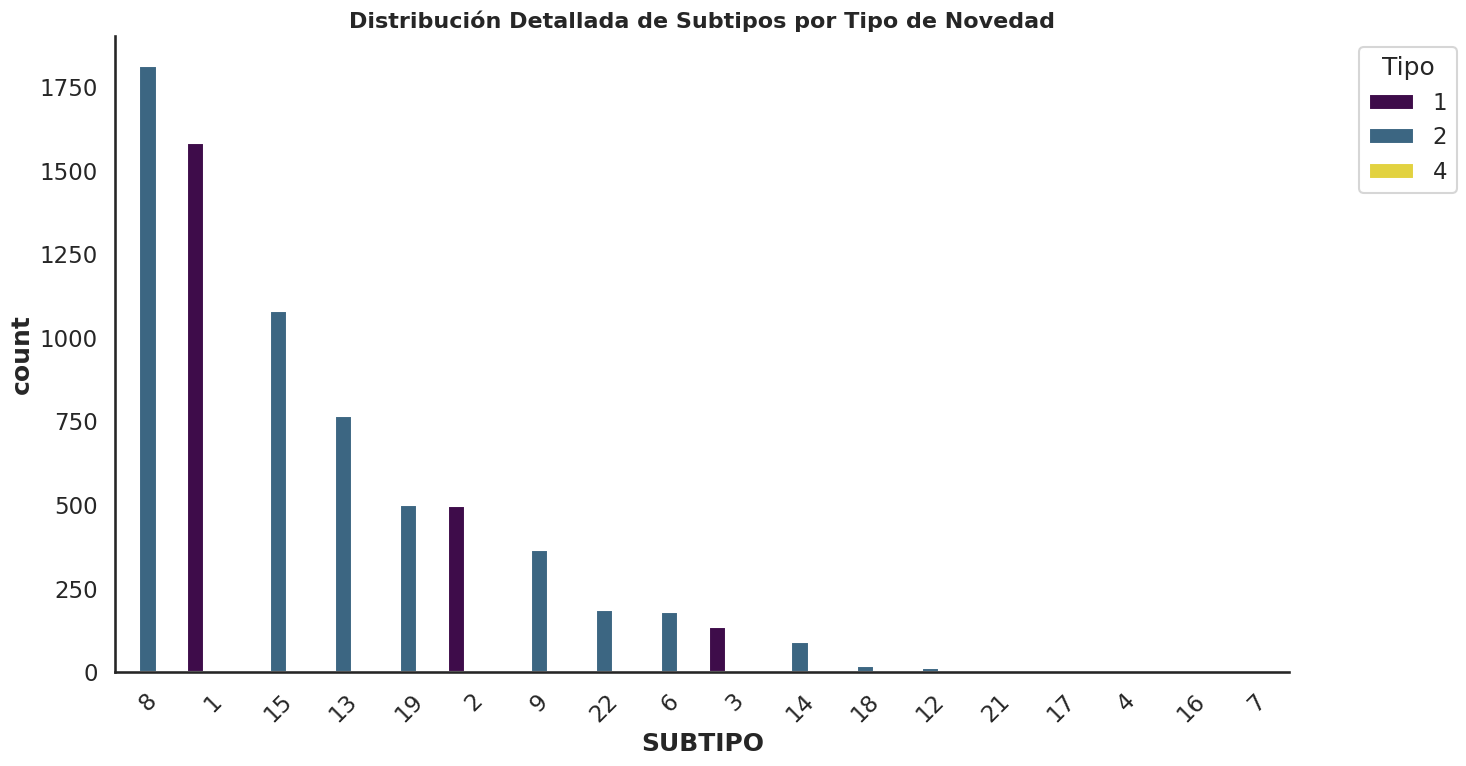

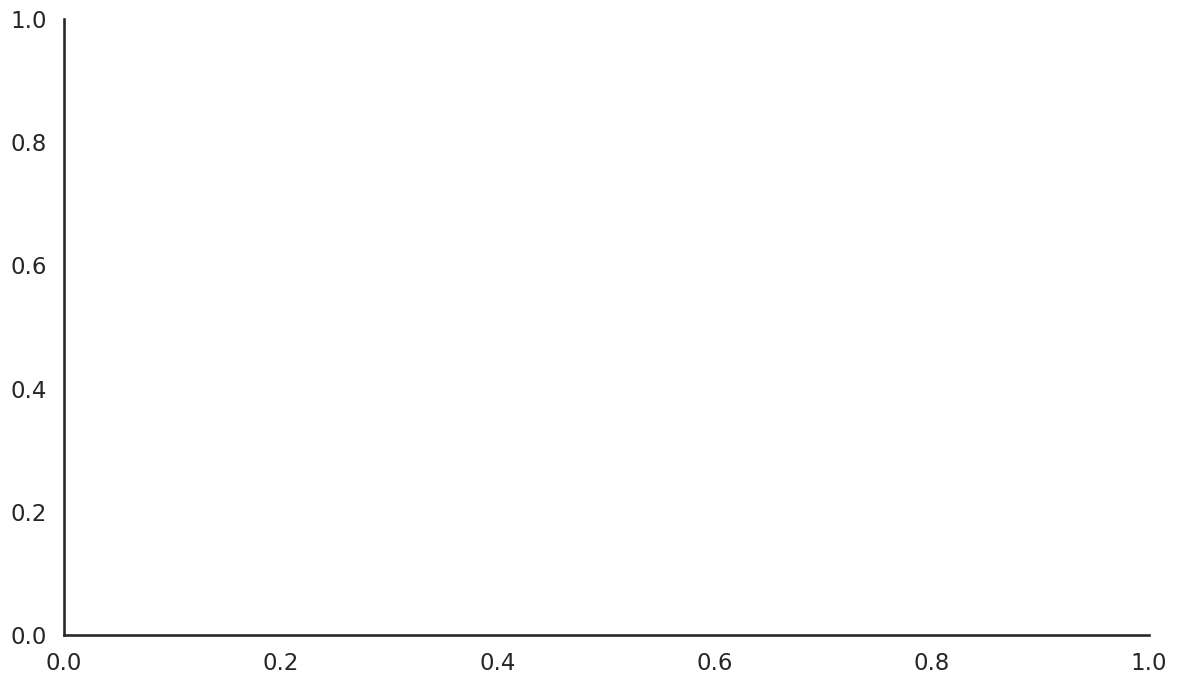

In [13]:
# Histograma Estilizado de Subtipos
plt.figure(figsize=(15, 8))
sns.countplot(data=datos_total, x='SUBTIPO', hue='TIPO', palette='viridis', order=datos_total['SUBTIPO'].value_counts().index)
plt.title('Distribución Detallada de Subtipos por Tipo de Novedad', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.legend(title='Tipo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Agregar etiquetas de valor
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()), ha="center", va="center", fontsize=11, color="black", xytext=(0, 7), textcoords="offset points")


### Visualizaciones Avanzadas de Estructura e Interacción
Nuevas perspectivas para entender la jerarquía y distribución del absentismo.

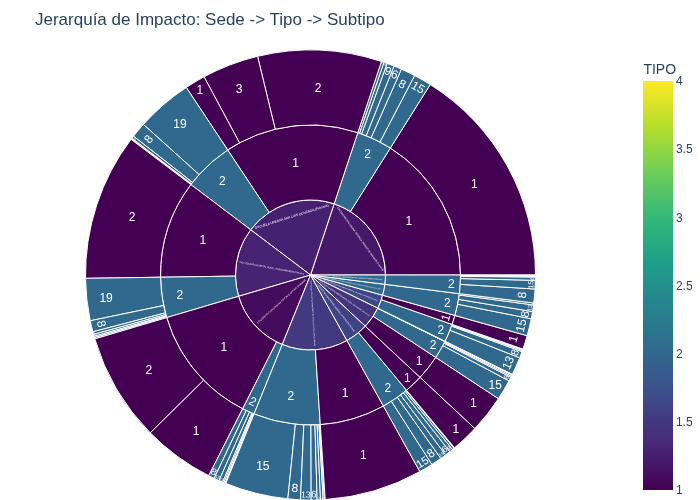

In [14]:
# 1. Sunburst Chart: Jerarquía Sede -> Tipo -> Subtipo
# Seleccionamos las sedes con más casos para evitar saturación
top_sedes = datos_total["NOMBRE_SEDE"].value_counts().nlargest(10).index
df_sunburst = datos_total[datos_total["NOMBRE_SEDE"].isin(top_sedes)]

fig_sun = px.sunburst(
    df_sunburst, 
    path=["NOMBRE_SEDE", "TIPO", "SUBTIPO"], 
    values="DIAS HABILES",
    color="TIPO",
    color_continuous_scale="Viridis",
    title="Jerarquía de Impacto: Sede -> Tipo -> Subtipo"
)
fig_sun.update_layout(margin=dict(t=50, l=0, r=0, b=0))
fig_sun.show()


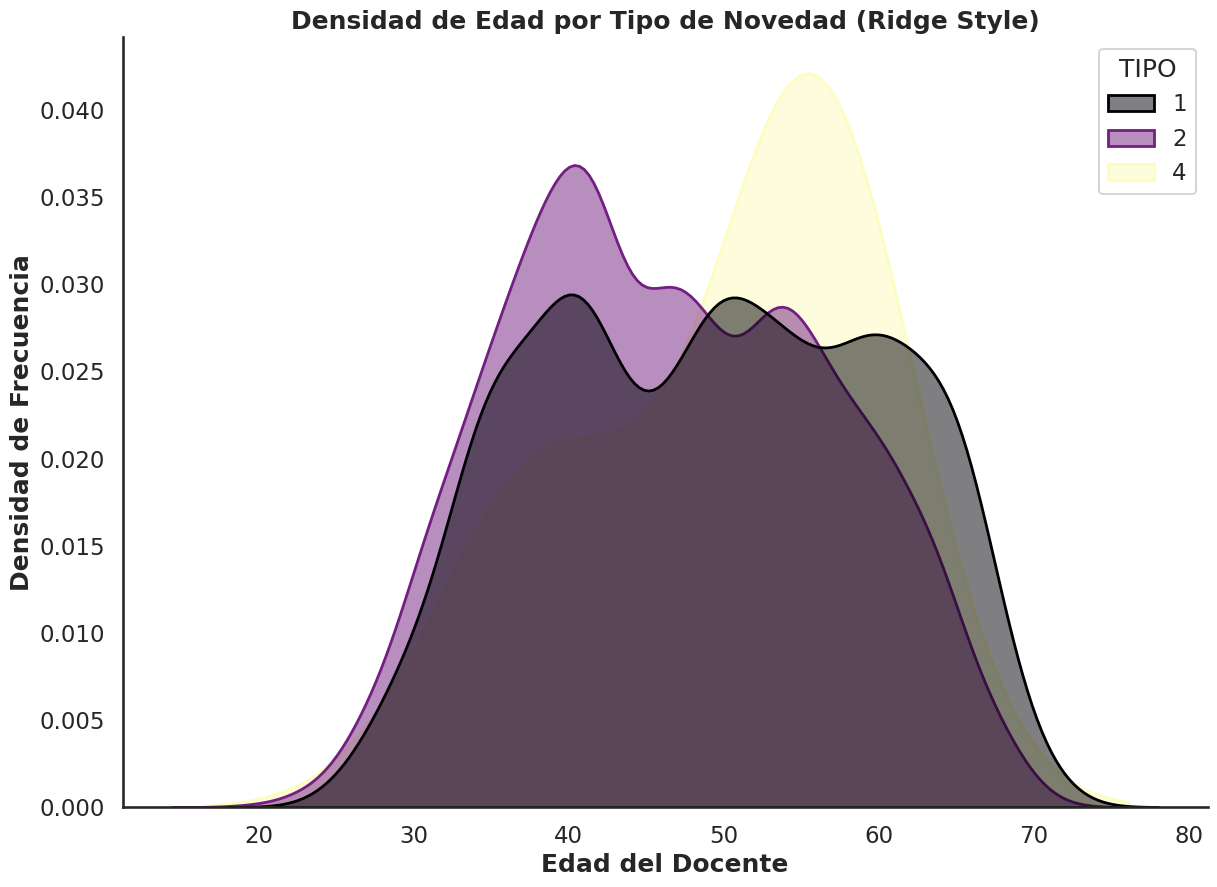

In [15]:
# 2. Ridge Plot: Distribución de Edad por Tipo de Novedad
plt.figure(figsize=(14, 10))
sns.kdeplot(
    data=datos_total, x="EDAD", hue="TIPO", 
    fill=True, common_norm=False, palette="magma", 
    alpha=.5, linewidth=2
)
plt.title("Densidad de Edad por Tipo de Novedad (Ridge Style)")
plt.xlabel("Edad del Docente")
plt.ylabel("Densidad de Frecuencia")
plt.show()


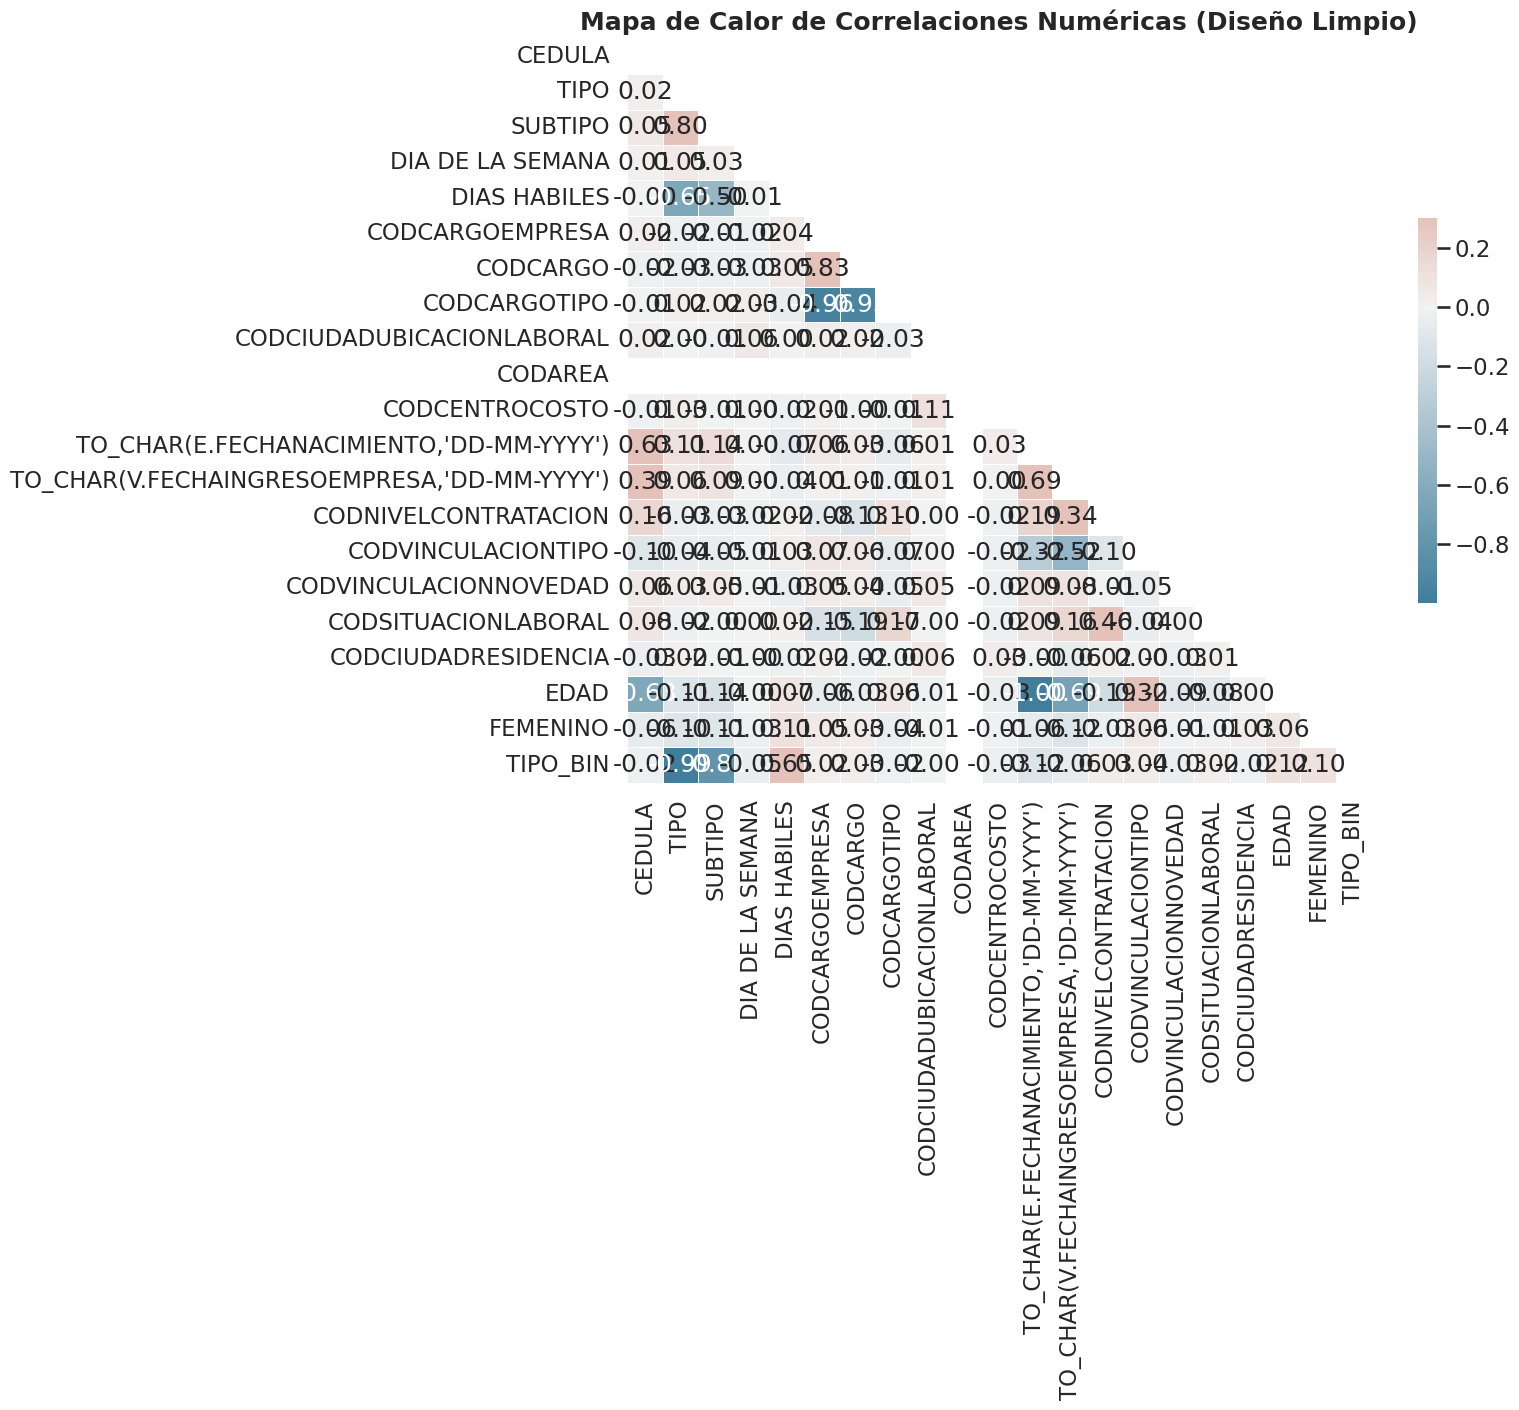

In [16]:
# 3. Stylized Heatmap de Correlaciones
corr = datos_total.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

f, ax = plt.subplots(figsize=(12, 10))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr, mask=mask, cmap=cmap, vmax=.3, center=0,
    square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True, fmt=".2f"
)
plt.title("Mapa de Calor de Correlaciones Numéricas (Diseño Limpio)")
plt.show()


In [17]:
datos2 = datos_total[['FECHA INICIAL', 'TIPO', 'SUBTIPO', 'EDAD', 'FEMENINO', 'RANGO DE EDAD']]

In [18]:
mca = prince.MCA()
mca.fit(datos2.drop('FECHA INICIAL', axis=1).astype(str))

,n_components,2
,n_iter,10
,copy,True
,check_input,True
,random_state,None
,engine,'sklearn'
,one_hot,True
,one_hot_prefix_sep,'__'
,one_hot_columns_to_drop,None
,correction,None


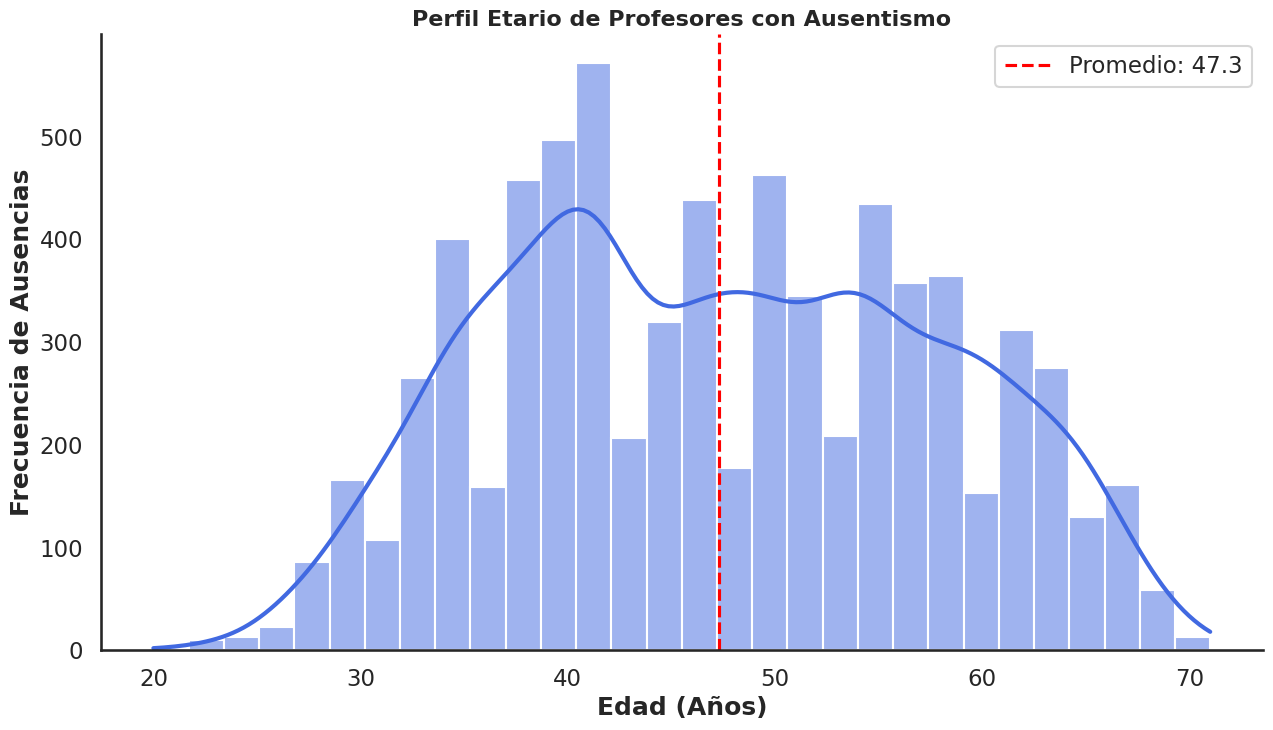

In [19]:
# Distribución de Edad con Curva de Densidad (KDE)
plt.figure(figsize=(15, 8))
sns.histplot(data=datos_total, x='EDAD', kde=True, bins=30, color='royalblue', line_kws={'linewidth': 3})
plt.axvline(datos_total['EDAD'].mean(), color='red', linestyle='--', label=f'Promedio: {datos_total['EDAD'].mean():.1f}')
plt.title('Perfil Etario de Profesores con Ausentismo', fontsize=16, fontweight='bold')
plt.xlabel('Edad (Años)')
plt.ylabel('Frecuencia de Ausencias')
plt.legend()
plt.show()


In [20]:
tabla_contingencia2 = pd.crosstab(datos_total['FECHA INICIAL'], [datos_total['EDAD'], datos_total['FEMENINO'], datos_total['RANGO DE EDAD']], margins=True)
tabla_contingencia2

EDAD                 20.0  23.0        24.0  25.0        26.0        27.0  \
FEMENINO                1     0     1     0     0     1     0     1     0   
RANGO DE EDAD       19-25 19-25 19-25 19-25 19-25 19-25 26-35 26-35 26-35   
FECHA INICIAL                                                               
2020-10-21 00:00:00     0     0     0     0     0     0     0     0     0   
2020-12-19 00:00:00     0     0     0     0     0     0     0     0     0   
2020-12-20 00:00:00     0     0     0     0     0     0     0     0     0   
2021-01-01 00:00:00     0     0     0     0     0     0     0     0     0   
2021-01-07 00:00:00     0     0     0     0     0     0     0     0     0   
...                   ...   ...   ...   ...   ...   ...   ...   ...   ...   
2022-09-19 00:00:00     0     0     0     0     0     0     0     0     0   
2022-09-20 00:00:00     0     0     0     0     0     0     0     0     0   
2022-09-21 00:00:00     0     0     0     0     0     0     0     0     0   
2022-09-28 00:00:00     0     0     0     0     0     0     0     0     0   
All                     2     6     4     2     2     9     6    16     7   

EDAD                       ... 67.0     68.0     69.0     70.0 71.0       All  
FEMENINO                1  ...    0   1    0   1    0   1    0    0   1        
RANGO DE EDAD       26-35  ...  66+ 66+  66+ 66+  66+ 66+  66+  66+ 66+        
FECHA INICIAL              ...                                                 
2020-10-21 00:00:00     0  ...    0   0    0   0    0   0    0    0   0     1  
2020-12-19 00:00:00     0  ...    0   0    0   0    0   0    0    0   0     1  
2020-12-20 00:00:00     0  ...    0   0    0   0    0   0    0    0   0     1  
2021-01-01 00:00:00     0  ...    0   0    0   0    0   0    0    0   0     1  
2021-01-07 00:00:00     0  ...    0   0    0   0    1   0    0    0   0     1  
...                   ...  ...  ...  ..  ...  ..  ...  ..  ...  ...  ..   ...  
2022-09-19 00:00:00     0  ...    0   0    0   0    0   0    0    0   0     4  
2022-09-20 00:00:00     0  ...    0   0    0   0    0   0    0    0   0     2  
2022-09-21 00:00:00     0  ...    0   0    0   0    0   0    0    0   0     2  
2022-09-28 00:00:00     0  ...    0   0    0   0    0   0    0    0   0     1  
All                    41  ...   37  57    1  18   20  19    6    5   2  7167  

[530 rows x 98 columns]

In [21]:
tabla_contingencia.describe()

TIPO               1                                                  \
SUBTIPO            1                       2                       3   
FEMENINO           0            1          0           1           1   
count      51.000000    51.000000  51.000000   51.000000   51.000000   
mean       13.529412    47.803922   3.686275   15.843137    5.137255   
std        47.763732   168.287019  13.321397   56.107173   18.460790   
min         0.000000     0.000000   0.000000    0.000000    0.000000   
25%         2.500000     8.000000   0.000000    1.000000    0.000000   
50%         5.000000    25.000000   0.000000    6.000000    0.000000   
75%        11.000000    36.000000   2.500000   13.000000    6.500000   
max       345.000000  1219.000000  94.000000  404.000000  131.000000   

TIPO                         2                                     ...  \
SUBTIPO           4          6                      7           8  ...   
FEMENINO          0          0           1          1           0  ...   
count     51.000000  51.000000   51.000000  51.000000   51.000000  ...   
mean       0.039216   2.196078    4.823529   0.039216   15.960784  ...   
std        0.196039   7.789787   17.037260   0.196039   56.178630  ...   
min        0.000000   0.000000    0.000000   0.000000    0.000000  ...   
25%        0.000000   0.000000    0.500000   0.000000    4.000000  ...   
50%        0.000000   1.000000    2.000000   0.000000    7.000000  ...   
75%        0.000000   2.000000    4.000000   0.000000   11.500000  ...   
max        1.000000  56.000000  123.000000   1.000000  407.000000  ...   

TIPO                                                                          \
SUBTIPO          17         18                     19                     22   
FEMENINO          1          0          1           0           1          0   
count     51.000000  51.000000  51.000000   51.000000   51.000000  51.000000   
mean       0.039216   0.156863   0.549020    4.666667   14.941176   2.705882   
std        0.196039   0.644129   1.993125   16.551334   52.575436   9.615184   
min        0.000000   0.000000   0.000000    0.000000    0.000000   0.000000   
25%        0.000000   0.000000   0.000000    0.000000    2.000000   0.000000   
50%        0.000000   0.000000   0.000000    2.000000    9.000000   1.000000   
75%        0.000000   0.000000   0.500000    4.000000   11.000000   2.500000   
max        1.000000   4.000000  14.000000  119.000000  381.000000  69.000000   

TIPO                          4                     All  
SUBTIPO                      13         21               
FEMENINO           1          1          1               
count      51.000000  51.000000  51.000000    51.000000  
mean        4.509804   0.039216   0.196078   281.058824  
std        16.025445   0.196039   0.775103   987.013098  
min         0.000000   0.000000   0.000000     2.000000  
25%         0.000000   0.000000   0.000000    80.500000  
50%         1.000000   0.000000   0.000000   159.000000  
75%         3.500000   0.000000   0.000000   210.000000  
max       115.000000   1.000000   5.000000  7167.000000  

[8 rows x 33 columns]

## Visualizaciones Avanzadas y Vistosas
Implementación de Plotly, Altair y Bokeh para un análisis más profundo y atractivo.

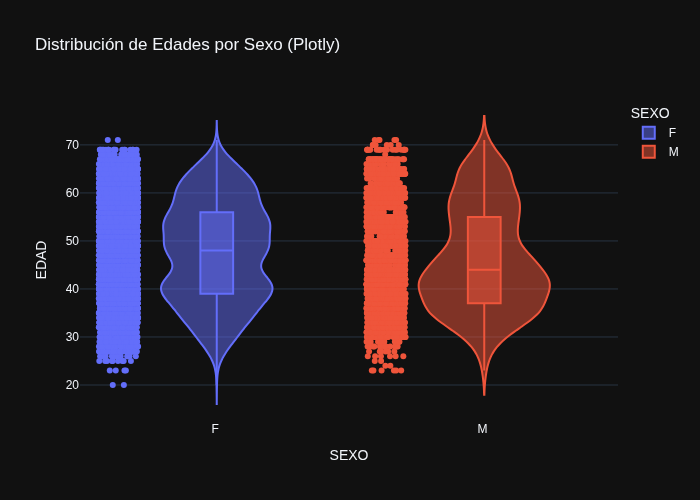

In [22]:
# 1. Plotly: Distribución Interactiva de Edades por Género
fig = px.violin(datos_total, y='EDAD', x='SEXO', color='SEXO', box=True, points='all', 
                title='Distribución de Edades por Sexo (Plotly)',
                template='plotly_dark')
fig.show()


In [23]:
# 2. Altair: Frecuencia de Subtipos
subtipo_counts = datos_total['SUBTIPO'].value_counts().reset_index()
chart = alt.Chart(subtipo_counts).mark_bar(cornerRadiusTopLeft=3, cornerRadiusTopRight=3).encode(
    x=alt.X('SUBTIPO:O', sort='-y'),
    y='count:Q',
    color=alt.Color('count:Q', scale=alt.Scale(scheme='viridis'))
).properties(title='Frecuencia de Subtipos (Altair)', width=600)
chart.display()


alt.Chart(...)

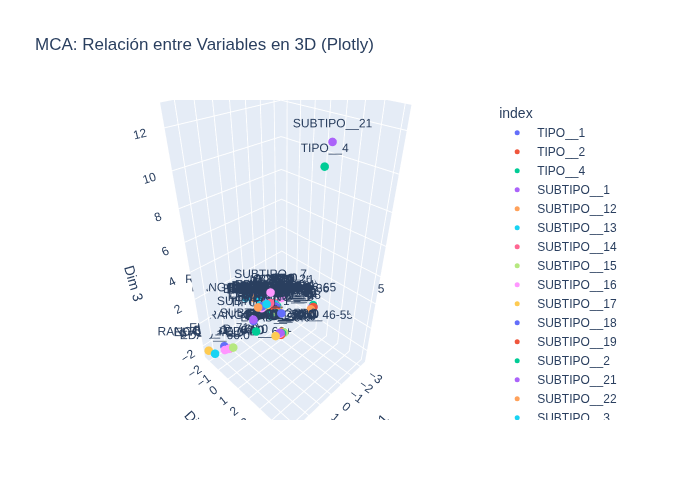

In [24]:
# 3. Plotly: Análisis de Correspondencias Múltiples (MCA) en 3D
# Usamos datos2 que ya está preparado para prince.MCA
mca_3d = prince.MCA(n_components=3)
mca_3d.fit(datos2.drop('FECHA INICIAL', axis=1).astype(str))
coords = mca_3d.column_coordinates(datos2.drop('FECHA INICIAL', axis=1).astype(str))

fig_mca = px.scatter_3d(coords, x=0, y=1, z=2, text=coords.index,
                        title='MCA: Relación entre Variables en 3D (Plotly)',
                        labels={'0': 'Dim 1', '1': 'Dim 2', '2': 'Dim 3'},
                        color=coords.index)
fig_mca.update_traces(marker=dict(size=5))
fig_mca.show()


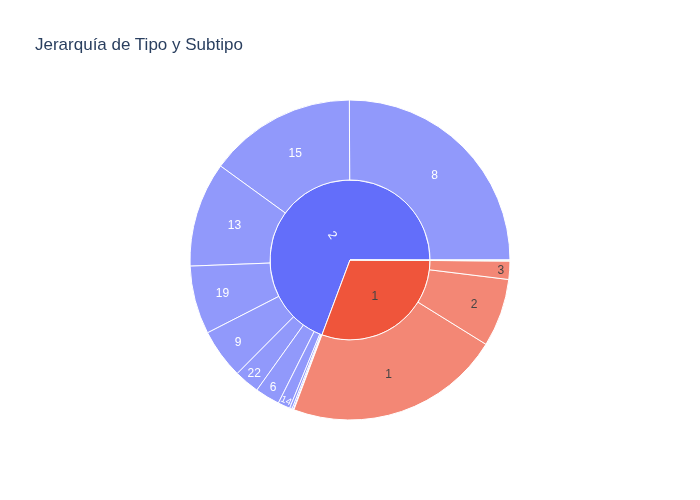

In [25]:
# 4. Plotly: Sunburst para Jerarquía de Tipo y Subtipo
fig_sun = px.sunburst(datos_total, path=['TIPO', 'SUBTIPO'], 
                      title='Jerarquía de Tipo y Subtipo',
                      color_continuous_scale='RdBu')
fig_sun.show()


## Visualizaciones Avanzadas y Vistosas
Implementación de Plotly, Altair y Bokeh para un análisis más profundo y atractivo.

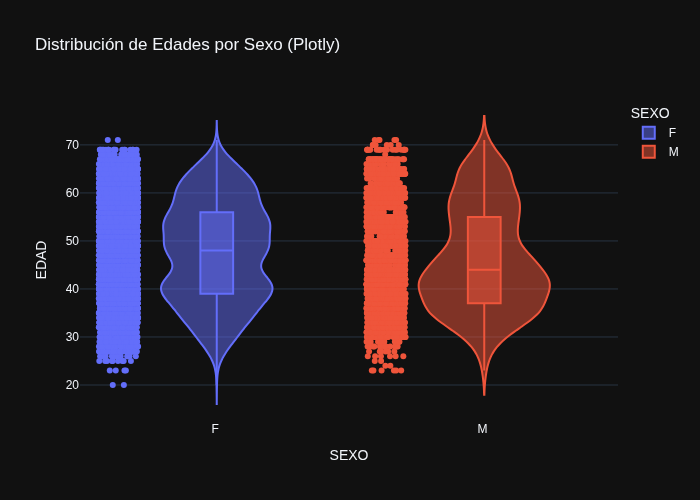

In [26]:
# 1. Plotly: Distribución Interactiva de Edades por Género
fig1 = px.violin(datos_total, y='EDAD', x='SEXO', color='SEXO', box=True, points='all', 
                title='Distribución de Edades por Sexo (Plotly)',
                template='plotly_dark')
fig1.show()


In [27]:
# 2. Altair: Frecuencia de Subtipos
subtipo_counts = datos_total['SUBTIPO'].value_counts().reset_index()
chart = alt.Chart(subtipo_counts).mark_bar(cornerRadiusTopLeft=3, cornerRadiusTopRight=3).encode(
    x=alt.X('SUBTIPO:O', sort='-y'),
    y='count:Q',
    color=alt.Color('count:Q', scale=alt.Scale(scheme='viridis'))
).properties(title='Frecuencia de Subtipos (Altair)', width=600)
try:
    chart.display()
except:
    print('Altair chart created')


alt.Chart(...)

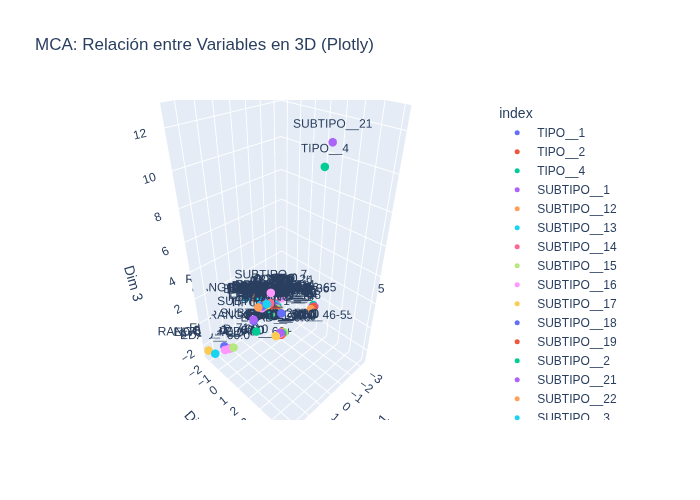

In [28]:
# 3. Plotly: Análisis de Correspondencias Múltiples (MCA) en 3D
mca_3d = prince.MCA(n_components=3)
mca_3d.fit(datos2.drop('FECHA INICIAL', axis=1).astype(str))
coords = mca_3d.column_coordinates(datos2.drop('FECHA INICIAL', axis=1).astype(str))

fig_mca = px.scatter_3d(coords, x=0, y=1, z=2, text=coords.index,
                        title='MCA: Relación entre Variables en 3D (Plotly)',
                        labels={'0': 'Dim 1', '1': 'Dim 2', '2': 'Dim 3'},
                        color=coords.index)
fig_mca.update_traces(marker=dict(size=5))
fig_mca.show()


### Visualizaciones Interactivas con Bokeh


In [29]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource
from bokeh.transform import factor_cmap
from bokeh.palettes import Spectral6

# Preparar datos para Bokeh
counts = datos_total['SEXO'].value_counts().reset_index()
counts.columns = ['SEXO', 'count']
source = ColumnDataSource(counts)

p = figure(x_range=counts['SEXO'].tolist(), title='Distribución por Sexo (Bokeh)',
           toolbar_location=None, tools='')

p.vbar(x='SEXO', top='count', width=0.9, source=source, legend_field='SEXO',
       line_color='white', fill_color=factor_cmap('SEXO', palette=Spectral6, factors=counts['SEXO'].tolist()))

p.xgrid.grid_line_color = None
p.y_range.start = 0
p.legend.orientation = 'horizontal'
p.legend.location = 'top_center'

show(p)


# Análisis Avanzado: Clustering y Profundización MCA
En esta sección realizamos una segmentación de datos y un análisis detallado de las contribuciones de las variables.

In [30]:
# Preparación de datos para MCA profundo
cols_para_mca = ['TIPO', 'SUBTIPO', 'SEXO', 'ZONA', 'RANGO DE EDAD', 'NIVELCONTRATACION']
df_mca = datos_total[cols_para_mca].copy().astype(str)

mca_final = prince.MCA(n_components=5)
mca_final.fit(df_mca)

# Obtener coordenadas de filas (individuos)
row_coords = mca_final.row_coordinates(df_mca)
print('Coordenadas MCA calculadas.')


Coordenadas MCA calculadas.


In [31]:
# Segmentación de Usuarios (K-Means sobre MCA)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(row_coords)
datos_total['Cluster'] = clusters.astype(str)

print(f'Segmentación completada en {n_clusters} clusters.')


Segmentación completada en 4 clusters.


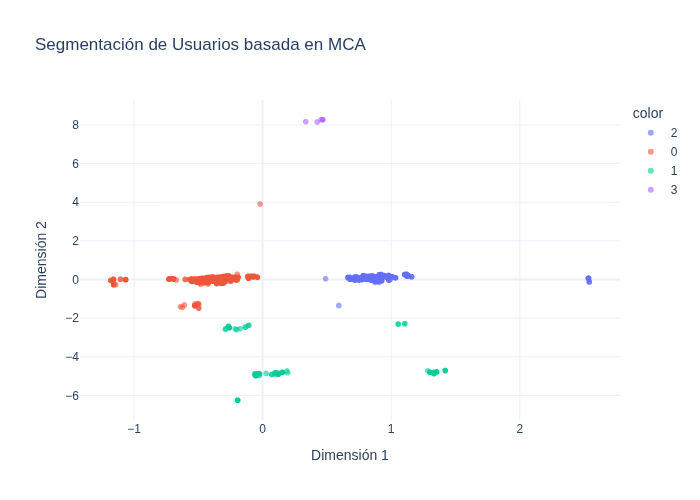

In [32]:
# Visualización de Clusters en 2D (MCA Dim 1 vs Dim 2)
fig_clusters = px.scatter(row_coords, x=0, y=1, color=datos_total['Cluster'],
                         title='Segmentación de Usuarios basada en MCA',
                         labels={'0': 'Dimensión 1', '1': 'Dimensión 2'},
                         template='plotly_white', opacity=0.6)
fig_clusters.show()


In [33]:
# Perfilado de Clusters: ¿Qué define a cada grupo?
cluster_profile = datos_total.groupby('Cluster')[['EDAD', 'TIPO', 'SUBTIPO']].agg(['mean', 'median'])
print('Perfil promedio de los clusters:')
display(cluster_profile)


Perfil promedio de los clusters:


EDAD             TIPO           SUBTIPO       
              mean median      mean median       mean median
Cluster                                                     
0        46.567094   46.0  2.000403    2.0  12.036312   13.0
1        42.655556   42.0  1.633333    2.0   8.555556    8.0
2        49.165201   50.0  1.000000    1.0   1.349221    1.0
3        52.800000   56.0  4.000000    4.0  21.000000   21.0

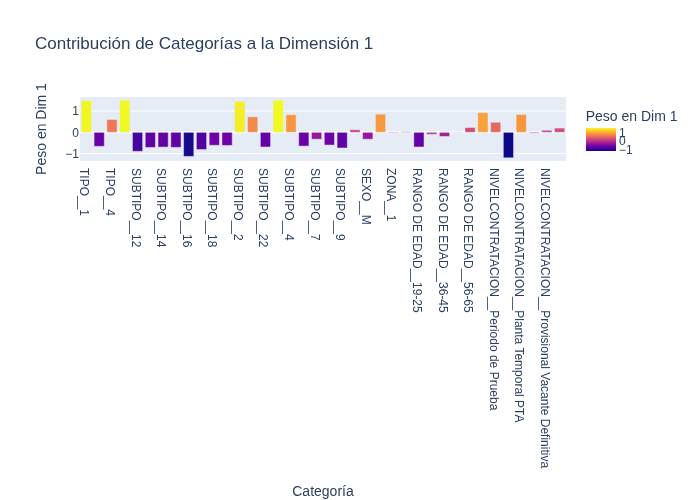

In [34]:
# Análisis de Contribuciones de Variables
col_coords = mca_final.column_coordinates(df_mca)
fig_contrib = px.bar(col_coords, y=0, x=col_coords.index, 
                     title='Contribución de Categorías a la Dimensión 1',
                     labels={'0': 'Peso en Dim 1', 'index': 'Categoría'},
                     color=col_coords[0])
fig_contrib.show()


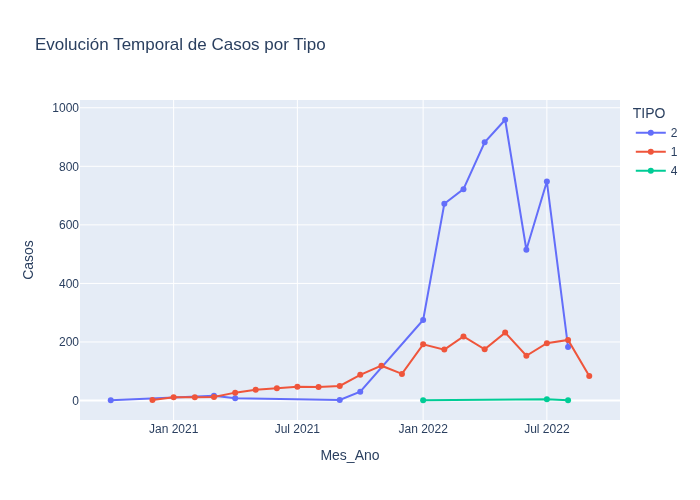

In [35]:
# Análisis Temporal: Evolución de Casos por Mes
datos_total['Mes_Ano'] = datos_total['FECHA INICIAL'].dt.to_period('M').astype(str)
temporal_trend = datos_total.groupby(['Mes_Ano', 'TIPO']).size().reset_index(name='Casos')

fig_time = px.line(temporal_trend, x='Mes_Ano', y='Casos', color='TIPO', 
                   title='Evolución Temporal de Casos por Tipo',
                   markers=True)
fig_time.show()


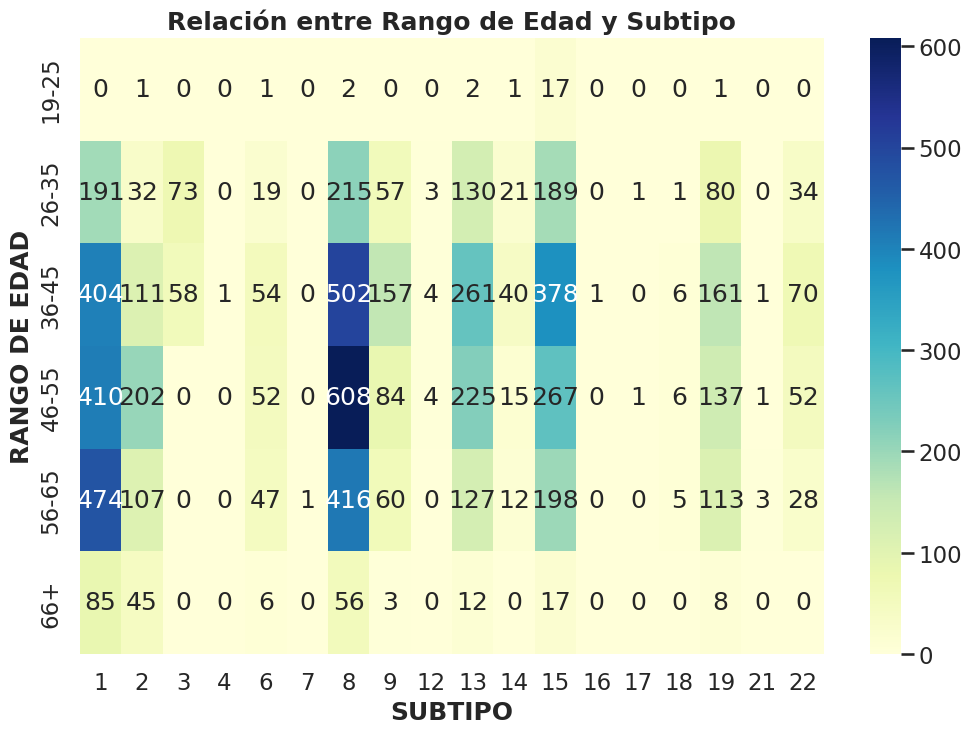

In [36]:
# Heatmap de Correlación entre Categorías (vía Cramer's V simplificado)
import seaborn as sns
plt.figure(figsize=(12, 8))
pivot_table = pd.crosstab(datos_total['RANGO DE EDAD'], datos_total['SUBTIPO'])
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Relación entre Rango de Edad y Subtipo')
plt.show()


# Análisis de Absentismo y Predicciones Futuras
En esta sección, nos enfocamos en predecir cuántos profesores se ausentarán y en qué sedes.

04:47:21 - cmdstanpy - INFO - Chain [1] start processing


04:47:21 - cmdstanpy - INFO - Chain [1] done processing


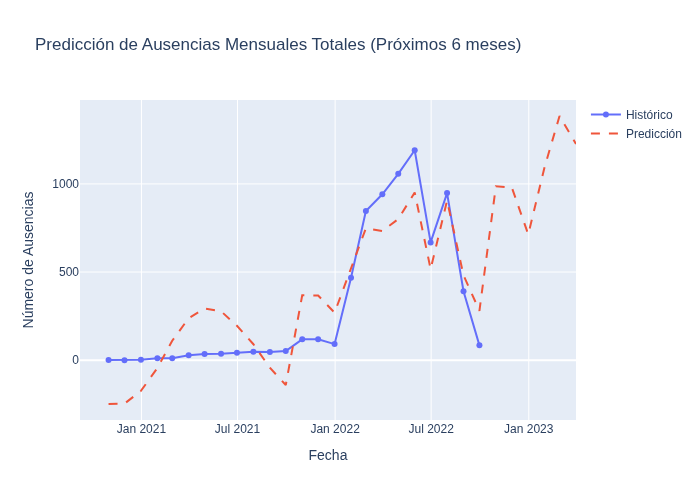

In [37]:
# 1. Agregación de datos por mes para Predicción de Volumen Total
df_time = datos_total.copy()
df_time['DS'] = pd.to_datetime(df_time['FECHA INICIAL'])
df_monthly = df_time.set_index('DS').resample('ME').size().reset_index()
df_monthly.columns = ['ds', 'y']

# Modelo Prophet para series temporales
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(df_monthly)

# Predicción para los próximos 6 meses
future = m.make_future_dataframe(periods=6, freq='ME')
forecast = m.predict(future)

fig_forecast = go.Figure()
fig_forecast.add_trace(go.Scatter(x=df_monthly['ds'], y=df_monthly['y'], name='Histórico', mode='markers+lines'))
fig_forecast.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat'], name='Predicción', line=dict(dash='dash')))
fig_forecast.update_layout(title='Predicción de Ausencias Mensuales Totales (Próximos 6 meses)', xaxis_title='Fecha', yaxis_title='Número de Ausencias')
fig_forecast.show()


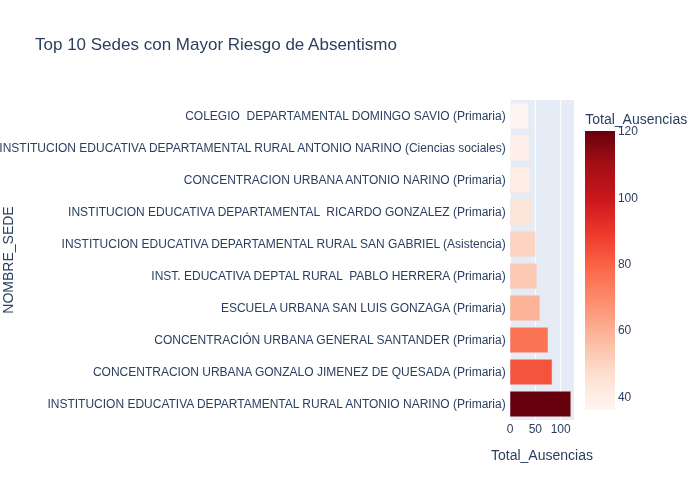

In [38]:
# 2. ¿Dónde se ausentarán? Análisis por Sede (Top 10 sedes críticas)
sede_risk = datos_total.groupby('NOMBRE_SEDE').size().reset_index(name='Total_Ausencias')
sede_risk = sede_risk.sort_values(by='Total_Ausencias', ascending=False).head(10)

fig_sede = px.bar(sede_risk, x='Total_Ausencias', y='NOMBRE_SEDE', orientation='h', 
                  title='Top 10 Sedes con Mayor Riesgo de Absentismo',
                  color='Total_Ausencias', color_continuous_scale='Reds')
fig_sede.show()


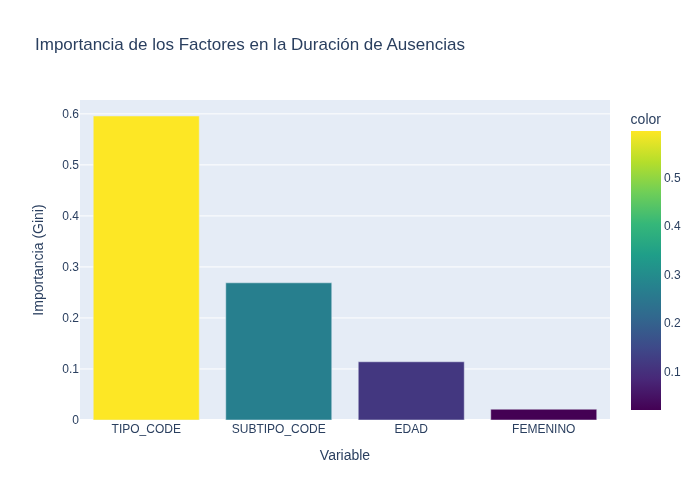

/tmp/ipykernel_873965/1060142175.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette="viridis")


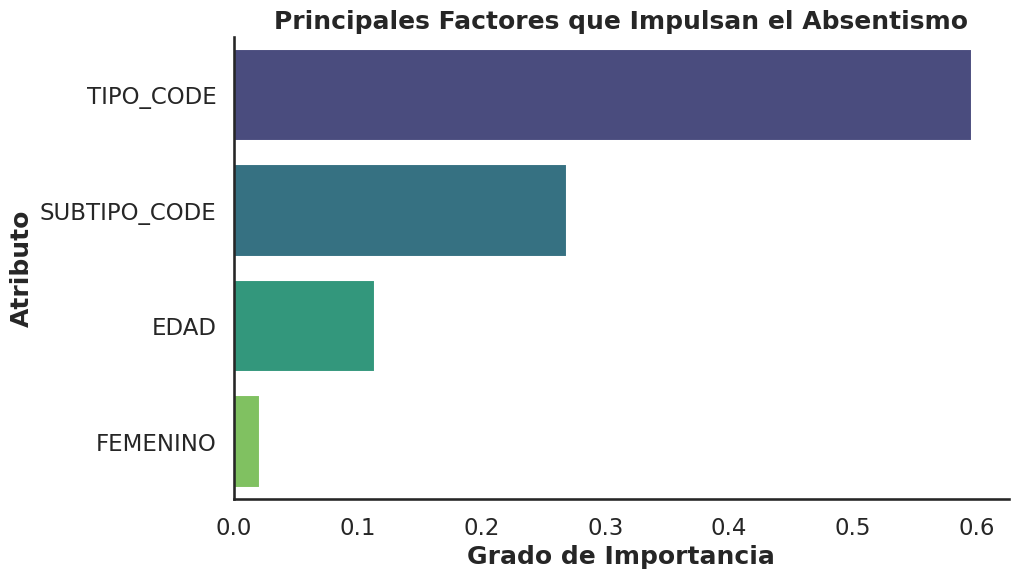

In [39]:
# 3. Modelo Predictivo de Riesgo Individual (Factores Clave)
from sklearn.preprocessing import LabelEncoder
df_model = datos_total[['EDAD', 'FEMENINO', 'TIPO', 'SUBTIPO', 'DIAS HABILES']].dropna().copy()

# Codificación de variables categóricas para Random Forest
le = LabelEncoder()
df_model['TIPO_CODE'] = le.fit_transform(df_model['TIPO'].astype(str))
df_model['SUBTIPO_CODE'] = le.fit_transform(df_model['SUBTIPO'].astype(str))

X = df_model[['EDAD', 'FEMENINO', 'TIPO_CODE', 'SUBTIPO_CODE']]
y = df_model['DIAS HABILES']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Definir importancia
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Visualización Plotly
fig_imp = px.bar(importance, title='Importancia de los Factores en la Duración de Ausencias',
                 labels={'value': 'Importancia (Gini)', 'index': 'Variable'},
                 color=importance.values, color_continuous_scale='Viridis')
fig_imp.show()

# Visualización Seaborn con Diseño Mejorado
plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index, palette="viridis")
plt.title("Principales Factores que Impulsan el Absentismo")
plt.xlabel("Grado de Importancia")
plt.ylabel("Atributo")
plt.show()


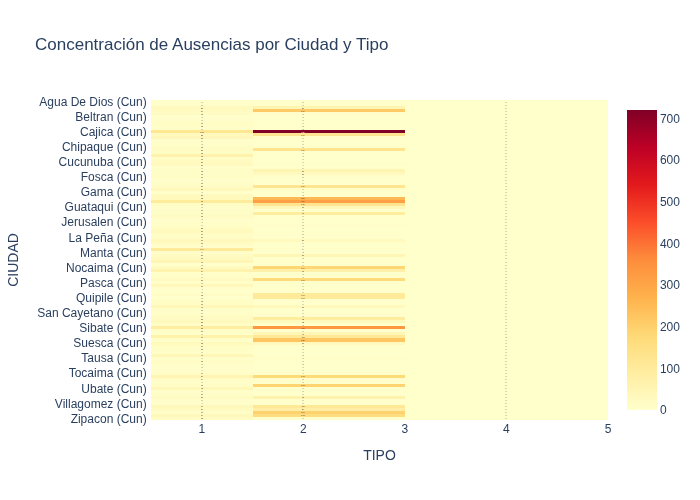

In [40]:
# 4. Mapa de Calor Geográfico (Ciudad vs Tipo de Ausencia)
geo_heatmap = pd.crosstab(datos_total['CIUDAD'], datos_total['TIPO'])
fig_geo = px.imshow(geo_heatmap, text_auto=True, aspect="auto", 
                    title='Concentración de Ausencias por Ciudad y Tipo',
                    color_continuous_scale='YlOrRd')
fig_geo.show()


In [41]:
# Análisis de correlación interactivo con Bokeh
from bokeh.models import HoverTool
p = figure(title='Edad vs Días Hábiles de Ausencia (Bokeh)', x_axis_label='Edad', y_axis_label='Días')
p.scatter('EDAD', 'DIAS HABILES', source=ColumnDataSource(datos_total.sample(1000)), size=8, alpha=0.5)
p.add_tools(HoverTool(tooltips=[('Sede', '@NOMBRE_SEDE'), ('Edad', '@EDAD')]))
show(p)


# Análisis de Absentismo: Saca el Jugo a los Datos
Exploración profunda de recurrencia, impacto geográfico y perfiles críticos.

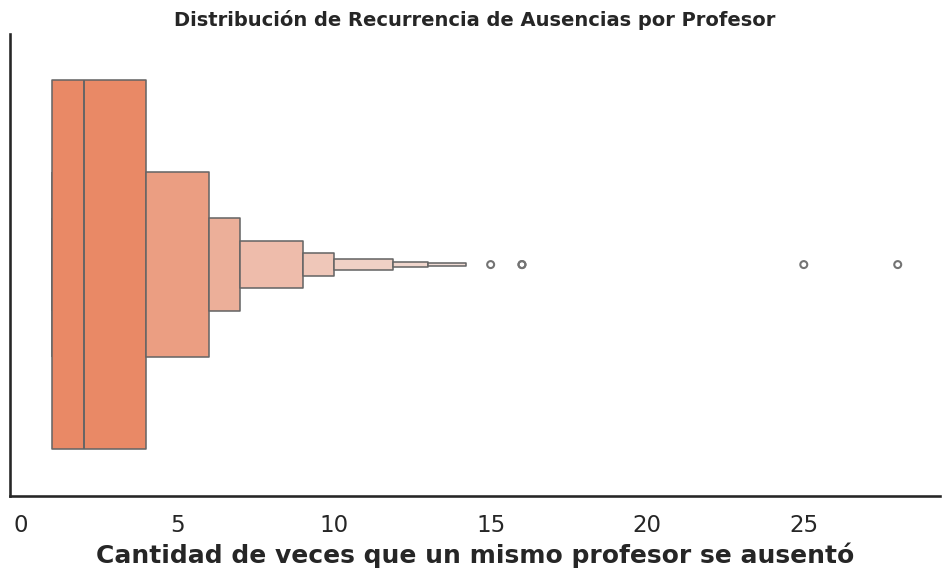

In [42]:
# 1. Análisis de Recurrencia: ¿Quiénes se ausentan más veces?
recurrencia = datos_total['CEDULA'].value_counts().reset_index()
recurrencia.columns = ['ID_Profesor', 'Numero_Ausencias']

plt.figure(figsize=(12, 6))
sns.boxenplot(data=recurrencia, x='Numero_Ausencias', color='coral')
plt.title('Distribución de Recurrencia de Ausencias por Profesor', fontsize=14)
plt.xlabel('Cantidad de veces que un mismo profesor se ausentó')
plt.show()


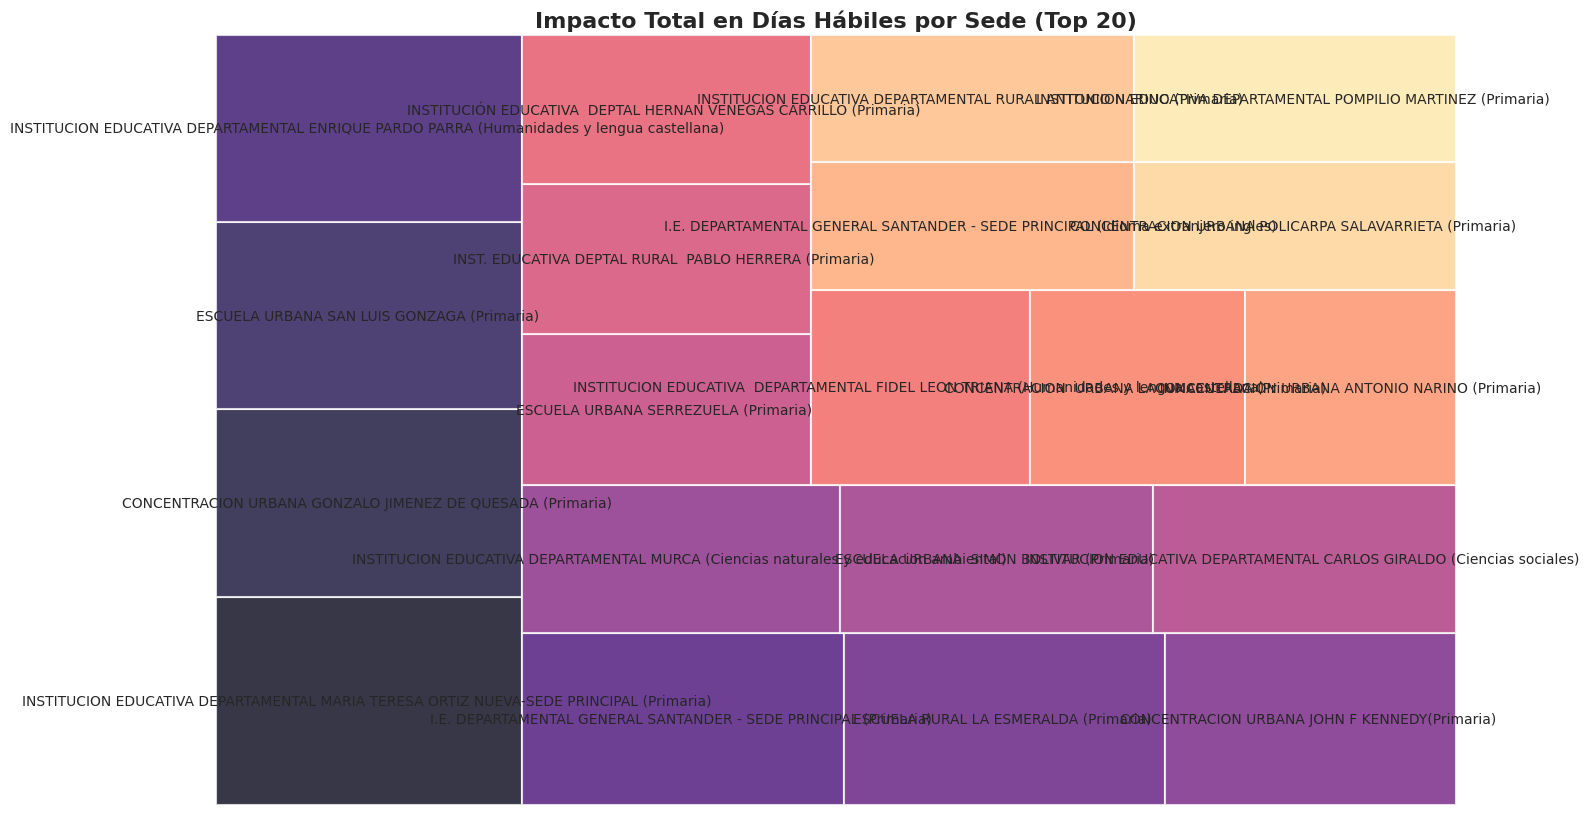

In [43]:
# 2. Treemap Profundo de Sedes y Días Perdidos
sede_impact = datos_total.groupby('NOMBRE_SEDE')['DIAS HABILES'].sum().reset_index()
sede_impact = sede_impact.sort_values(by='DIAS HABILES', ascending=False).head(20)

plt.figure(figsize=(16, 10))
squarify.plot(sizes=sede_impact['DIAS HABILES'], label=sede_impact['NOMBRE_SEDE'], 
              alpha=.8, color=sns.color_palette('magma', len(sede_impact)), text_kwargs={'fontsize':10})
plt.title('Impacto Total en Días Hábiles por Sede (Top 20)', fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()


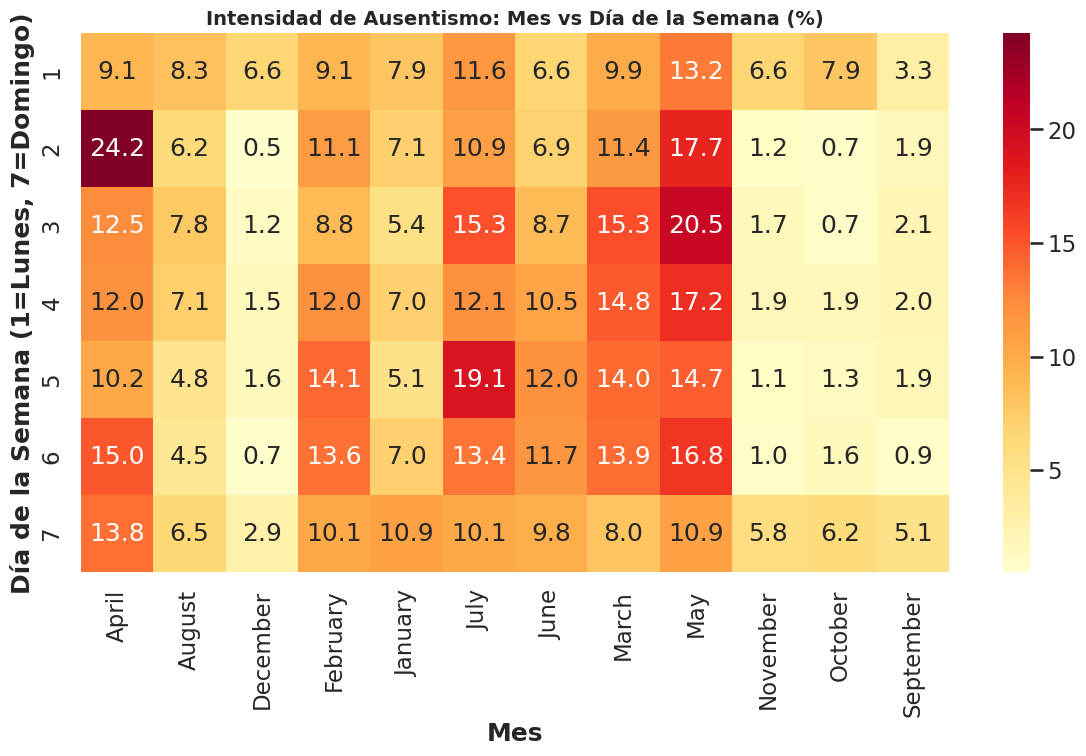

In [44]:
# 3. Análisis de Pico Temporal: ¿Qué días de la semana y meses son críticos?
temp_map = pd.crosstab(datos_total['DIA DE LA SEMANA'], 
                       datos_total['FECHA INICIAL'].dt.month_name(),
                       normalize='index') * 100

plt.figure(figsize=(14, 7))
sns.heatmap(temp_map, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Intensidad de Ausentismo: Mes vs Día de la Semana (%)', fontsize=14)
plt.ylabel('Día de la Semana (1=Lunes, 7=Domingo)')
plt.xlabel('Mes')
plt.show()


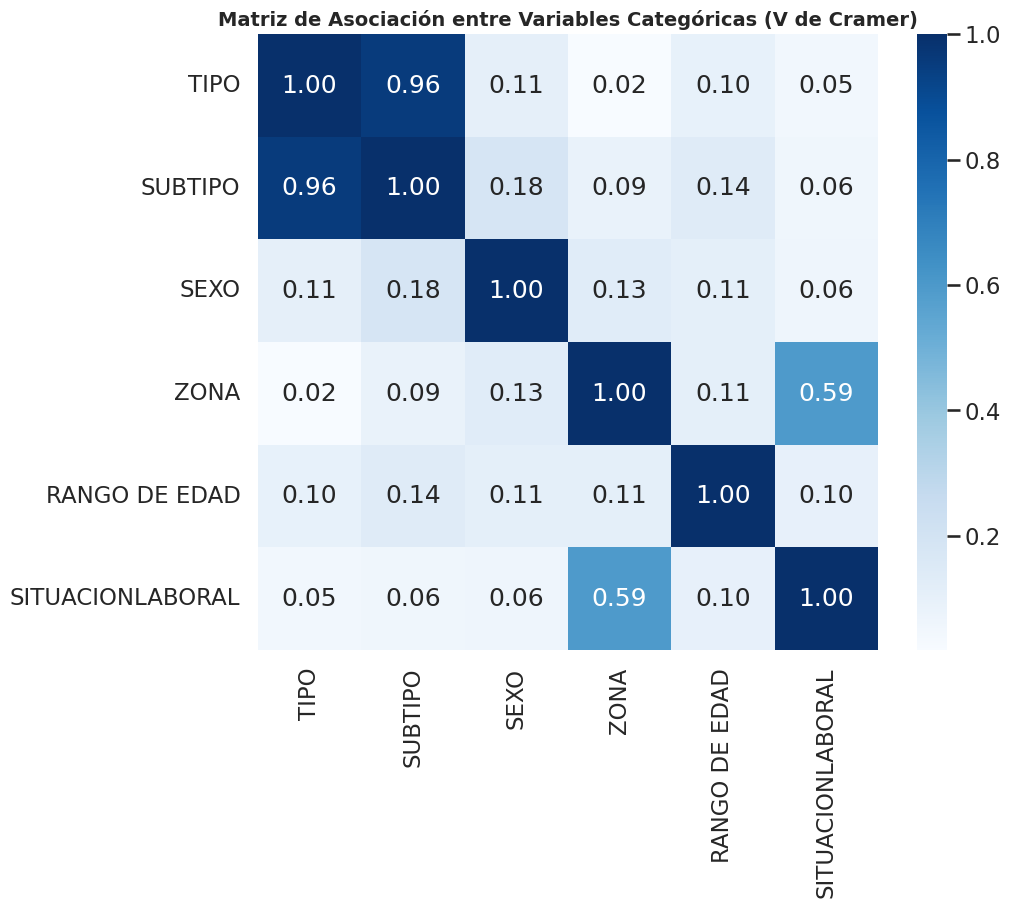

In [45]:
# 4. Análisis de Correlación de Categorías (Heatmap de Cramer's V)
from scipy.stats import chi2_contingency
def cramers_v_matrix(df):
    cols = df.columns
    n = len(df)
    matrix = np.zeros((len(cols), len(cols)))
    for i in range(len(cols)):
        for j in range(len(cols)):
            if i == j: matrix[i,j] = 1; continue
            tab = pd.crosstab(df[cols[i]], df[cols[j]])
            chi2 = chi2_contingency(tab)[0]
            matrix[i,j] = np.sqrt(chi2 / (n * (min(tab.shape)-1)))
    return pd.DataFrame(matrix, index=cols, columns=cols)

cat_cols = ['TIPO', 'SUBTIPO', 'SEXO', 'ZONA', 'RANGO DE EDAD', 'SITUACIONLABORAL']
cv_mat = cramers_v_matrix(datos_total[cat_cols].astype(str))

plt.figure(figsize=(10, 8))
sns.heatmap(cv_mat, annot=True, cmap='Blues', fmt='.2f')
plt.title('Matriz de Asociación entre Variables Categóricas (V de Cramer)', fontsize=14)
plt.show()


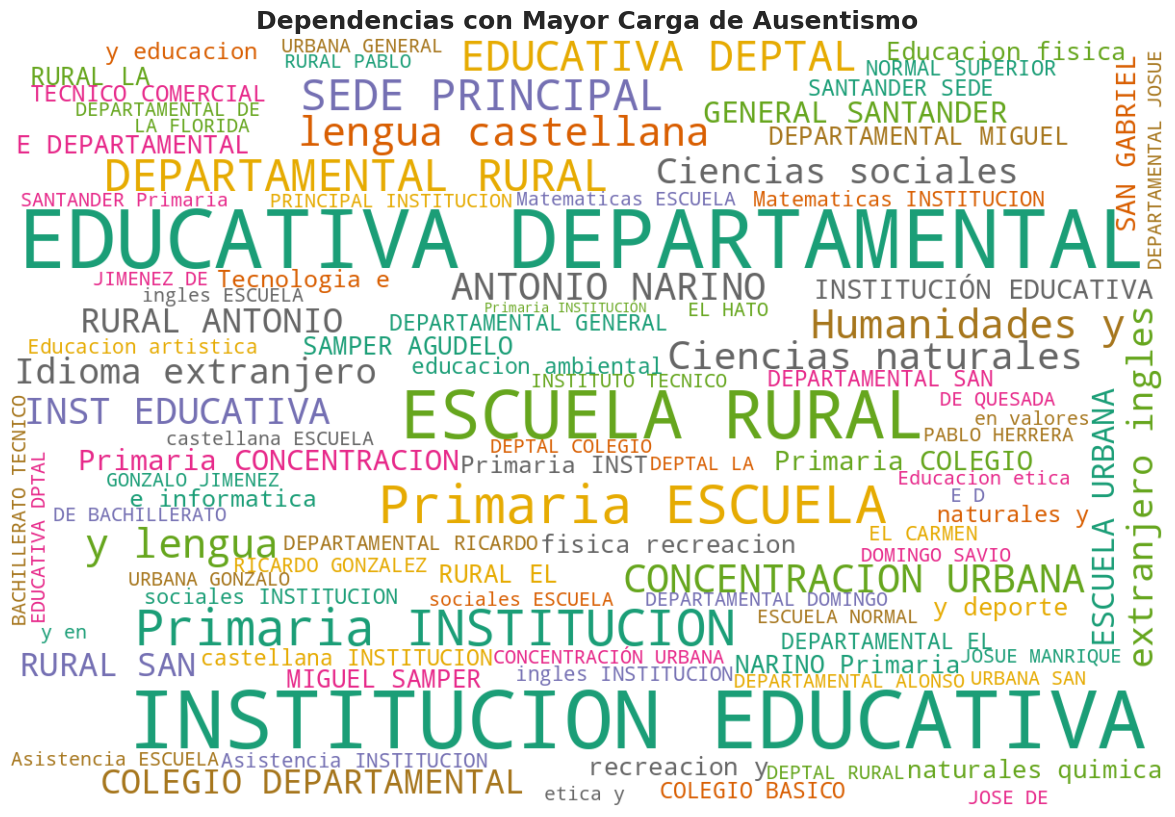

In [46]:
# 5. Análisis de Frecuencia de Dependencias (WordCloud)
text = " ".join(str(dep) for dep in datos_total.DEPENDENCIA if pd.notnull(dep))
wordcloud = WordCloud(width=1200, height=800, background_color="white", colormap="Dark2", max_words=100).generate(text)
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.title("Dependencias con Mayor Carga de Ausentismo", fontsize=18)
plt.axis("off")
plt.show()


## Detección de Anomalías y Puntuación de Riesgo
Identificación de patrones inusuales y asignación de nivel de riesgo por docente.

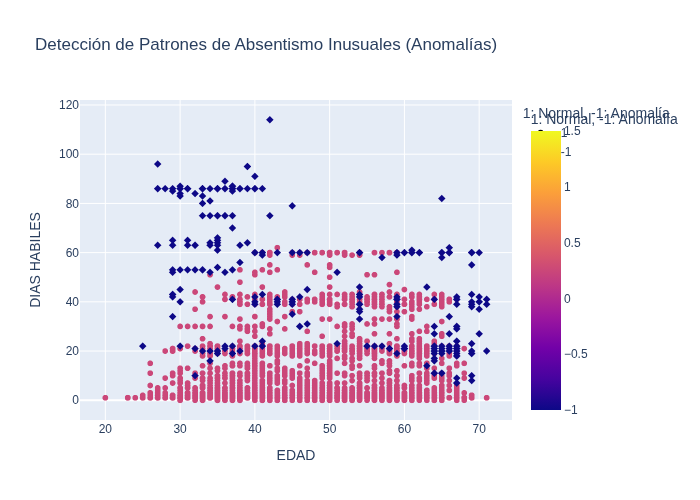

In [47]:
# 1. Detección de Anomalías (Isolation Forest)
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_anom = datos_total[['EDAD', 'DIAS HABILES', 'FEMENINO']].fillna(0)
datos_total['Anomaly'] = iso_forest.fit_predict(df_anom)

fig_anom = px.scatter(datos_total, x='EDAD', y='DIAS HABILES', color='Anomaly', 
                     symbol='Anomaly', title='Detección de Patrones de Absentismo Inusuales (Anomalías)',
                     labels={'Anomaly': '1: Normal, -1: Anomalía'},
                     color_discrete_map={'1': 'blue', '-1': 'red'})
fig_anom.show()


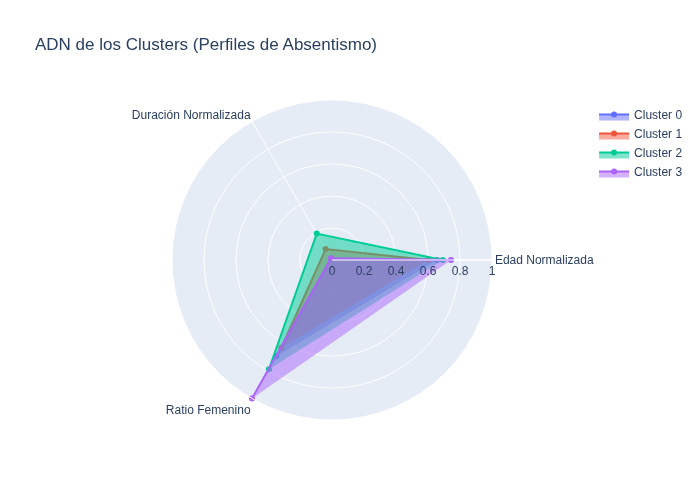

In [48]:
# 2. Perfiles de Cluster en Gráfico de Radar (Plotly)
cluster_means = datos_total.groupby('Cluster')[['EDAD', 'DIAS HABILES', 'FEMENINO']].mean().reset_index()
fig_radar = go.Figure()

for i, row in cluster_means.iterrows():
    fig_radar.add_trace(go.Scatterpolar(
        r=[row['EDAD']/datos_total['EDAD'].max(), row['DIAS HABILES']/datos_total['DIAS HABILES'].max(), row['FEMENINO']],
        theta=['Edad Normalizada', 'Duración Normalizada', 'Ratio Femenino'],
        fill='toself', name=f'Cluster {row["Cluster"]}'
    ))

fig_radar.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0, 1])), 
                        title='ADN de los Clusters (Perfiles de Absentismo)')
fig_radar.show()


In [49]:
# 3. Scoring de Riesgo por Docente
# Un score basado en recurrencia y días totales
docente_score = datos_total.groupby('CEDULA').agg({
    'DIAS HABILES': 'sum',
    'TIPO': 'count'
}).rename(columns={'DIAS HABILES': 'Total_Dias', 'TIPO': 'Frecuencia'})
docente_score['Risk_Score'] = (docente_score['Total_Dias'] * 0.7) + (docente_score['Frecuencia'] * 0.3)
docente_top_risk = docente_score.sort_values(by='Risk_Score', ascending=False).head(10)

print("Top 10 Docentes con mayor puntaje de riesgo:")
display(docente_top_risk)


Top 10 Docentes con mayor puntaje de riesgo:


,Total_Dias,Frecuencia,Risk_Score
CEDULA,,,
19186936,376,7,265.3
20571771,344,8,243.2
50902530,314,6,221.6
20625417,303,7,214.2
20975655,287,13,204.8
23415719,288,7,203.7
30350278,284,5,200.3
41771693,283,7,200.2
51793823,283,6,199.9


# Tablero de Control de Mando (Visualizaciones de Élite)
Análisis sistémico del flujo de absentismo y redes de asociación.

In [50]:
# Visualización de KPIs con Estilo de Tablero
from IPython.display import HTML

total_dias = datos_total["DIAS HABILES"].sum()
promedio_dias = datos_total["DIAS HABILES"].mean()
total_casos = len(datos_total)

html_kpis = f"""
<div style="display: flex; justify-content: space-around; background-color: #f8f9fa; padding: 20px; border-radius: 10px; border: 1px solid #dee2e6;">
    <div style="text-align: center;">
        <h2 style="color: #4a4a4a; margin-bottom: 5px;">{total_dias:,.0f}</h2>
        <p style="color: #6c757d; font-size: 14px;">Total Días de Ausencia</p>
    </div>
    <div style="text-align: center; border-left: 1px solid #dee2e6; border-right: 1px solid #dee2e6; padding: 0 40px;">
        <h2 style="color: #4a4a4a; margin-bottom: 5px;">{promedio_dias:.2f}</h2>
        <p style="color: #6c757d; font-size: 14px;">Promedio Días / Caso</p>
    </div>
    <div style="text-align: center;">
        <h2 style="color: #4a4a4a; margin-bottom: 5px;">{total_casos:,.0f}</h2>
        <p style="color: #6c757d; font-size: 14px;">Total de Registros</p>
    </div>
</div>
"""
display(HTML(html_kpis))


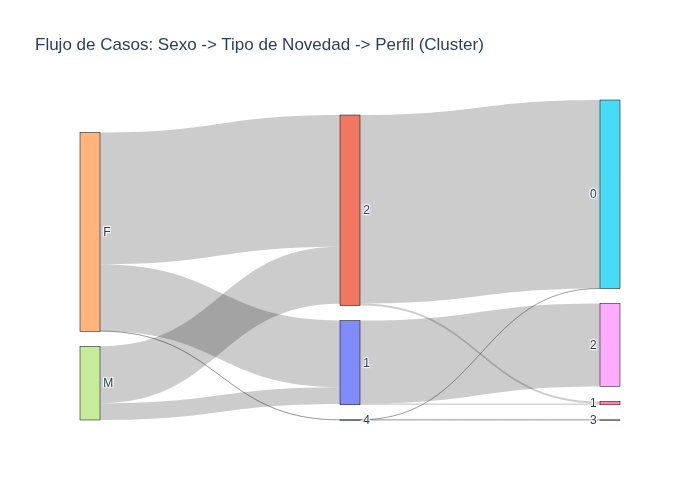

In [51]:
# 2. Sankey Diagram: Flujo de Absentismo por Sexo, Tipo y Cluster
def make_sankey(df, cols):
    labels = []
    for col in cols: labels.extend(df[col].unique().tolist())
    labels = list(set(labels))
    label_map = {l: i for i, l in enumerate(labels)}
    
    sources, targets, values = [], [], []
    for i in range(len(cols)-1):
        s_col, t_col = cols[i], cols[i+1]
        counts = df.groupby([s_col, t_col]).size().reset_index(name='count')
        sources.extend([label_map[s] for s in counts[s_col]])
        targets.extend([label_map[t] for t in counts[t_col]])
        values.extend(counts['count'])
    
    return go.Figure(data=[go.Sankey(
        node = dict(pad=15, thickness=20, line=dict(color="black", width=0.5), label=labels),
        link = dict(source=sources, target=targets, value=values)
    )])

fig_sankey = make_sankey(datos_total, ['SEXO', 'TIPO', 'Cluster'])
fig_sankey.update_layout(title_text="Flujo de Casos: Sexo -> Tipo de Novedad -> Perfil (Cluster)", font_size=12)
fig_sankey.show()


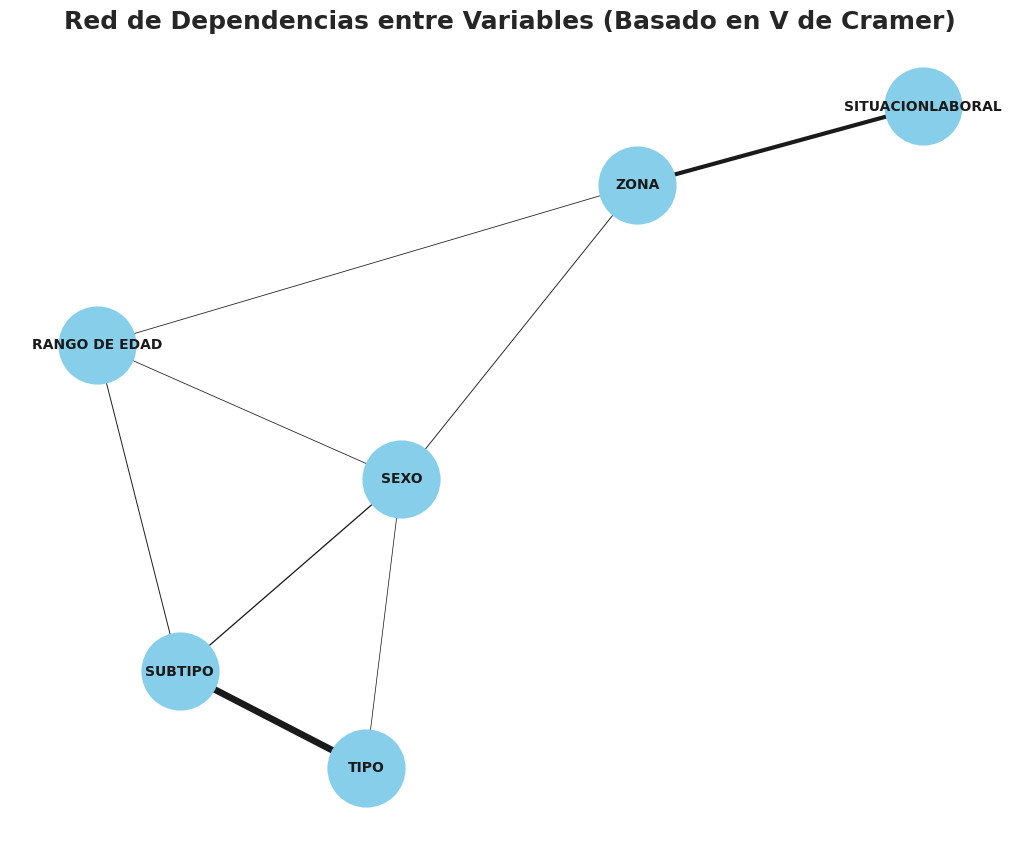

In [52]:
# 3. Network Graph: Red de Asociaciones Categóricas
# Usamos la matriz de Cramer's V calculada anteriormente (cv_mat)
G = nx.Graph()
for i in range(len(cv_mat.columns)):
    for j in range(i+1, len(cv_mat.columns)):
        weight = cv_mat.iloc[i, j]
        if weight > 0.1: # Solo conexiones significativas
            G.add_edge(cv_mat.columns[i], cv_mat.columns[j], weight=weight)

pos = nx.spring_layout(G)
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=3000, font_size=10, font_weight='bold', 
        width=[G[u][v]['weight']*5 for u,v in G.edges()])
plt.title("Red de Dependencias entre Variables (Basado en V de Cramer)")
plt.show()


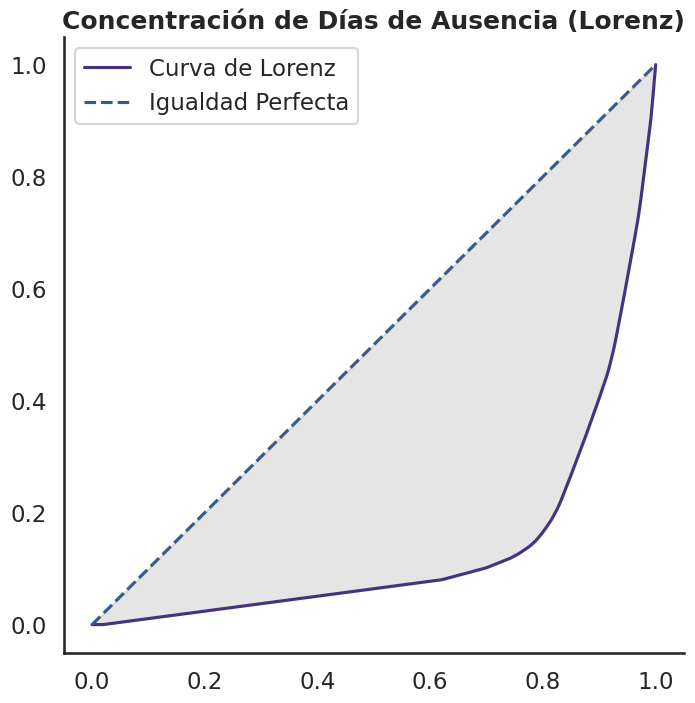

In [53]:
# 4. Curva de Concentración (Lorenz) de Días de Absentismo
def plot_lorenz(values, title):
    n = len(values)
    scaled_prefix_sum = np.cumsum(np.sort(values)) / np.sum(values)
    lorenz_curve = np.insert(scaled_prefix_sum, 0, 0)
    plt.figure(figsize=(8, 8))
    plt.plot(np.linspace(0, 1, n + 1), lorenz_curve, label='Curva de Lorenz')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Igualdad Perfecta')
    plt.fill_between(np.linspace(0, 1, n + 1), np.linspace(0, 1, n + 1), lorenz_curve, color='gray', alpha=0.2)
    plt.title(title)
    plt.legend()
    plt.show()

plot_lorenz(datos_total['DIAS HABILES'].values, "Concentración de Días de Ausencia (Lorenz)")


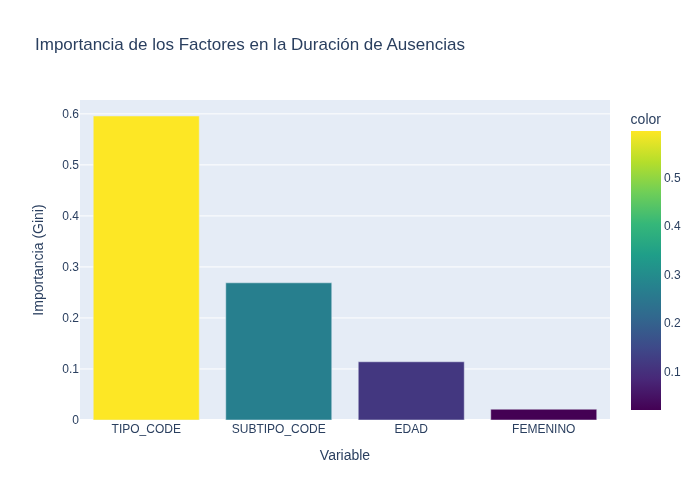

/tmp/ipykernel_873965/1060142175.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette="viridis")


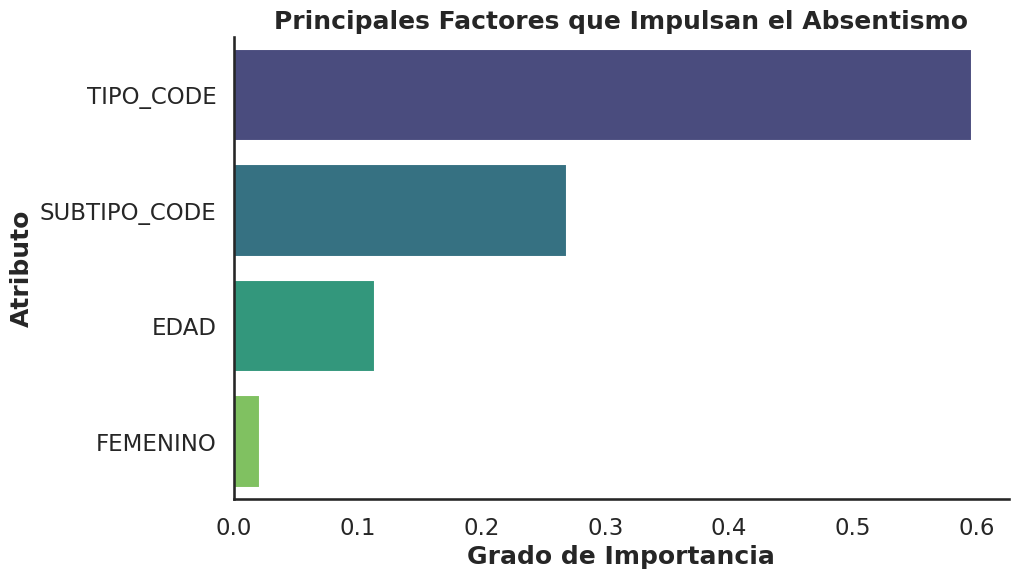

In [54]:
# 3. Modelo Predictivo de Riesgo Individual (Factores Clave)
from sklearn.preprocessing import LabelEncoder
df_model = datos_total[['EDAD', 'FEMENINO', 'TIPO', 'SUBTIPO', 'DIAS HABILES']].dropna().copy()

# Codificación de variables categóricas para Random Forest
le = LabelEncoder()
df_model['TIPO_CODE'] = le.fit_transform(df_model['TIPO'].astype(str))
df_model['SUBTIPO_CODE'] = le.fit_transform(df_model['SUBTIPO'].astype(str))

X = df_model[['EDAD', 'FEMENINO', 'TIPO_CODE', 'SUBTIPO_CODE']]
y = df_model['DIAS HABILES']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Definir importancia
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Visualización Plotly
fig_imp = px.bar(importance, title='Importancia de los Factores en la Duración de Ausencias',
                 labels={'value': 'Importancia (Gini)', 'index': 'Variable'},
                 color=importance.values, color_continuous_scale='Viridis')
fig_imp.show()

# Visualización Seaborn con Diseño Mejorado
plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index, palette="viridis")
plt.title("Principales Factores que Impulsan el Absentismo")
plt.xlabel("Grado de Importancia")
plt.ylabel("Atributo")
plt.show()
